In [3]:
import os
import tempfile

import pandas as pd
import numpy as np
import re

import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go


import statsmodels.formula.api as smf
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.distributions.empirical_distribution import ECDF

from sklearn.preprocessing import StandardScaler, MinMaxScaler, OneHotEncoder, LabelEncoder
from sklearn.impute import SimpleImputer

import warnings
warnings.filterwarnings('ignore')
warnings.simplefilter(action='ignore', category=FutureWarning)

In [4]:
def pd_read_parquet(artifact_path: str) -> pd.DataFrame:
    '''
    This function should read a Parquet file located at the provided path and return a pandas DataFrame.
    '''
    return pd.read_parquet(artifact_path)

path = 'data (1).parquet'
df = pd_read_parquet(path)
df.head()


,user_id,ts,active_time_m7,active_time_m14,active_time_s7,active_time_s14,activity_percent_m7,activity_percent_m14,activity_percent_s7,activity_percent_s14,...,phq_q4,phq_q5,phq_q6,phq_q7,phq_q8,phq_q9,phq2_total,phq8_total,phq9_total,deployment
0,us-east-1:1b087523-b47b-421c-97c4-74da80564598,2018-09-25 18:17:26.647,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,2.0,0.0,1.0,1.0,1.0,NaN,3.0,9.0,NaN,hr-rct-cue-1
1,us-east-1:ea986d8e-e87d-458b-a798-1999fbbff05b,2018-09-26 17:13:52.394,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,3.0,3.0,3.0,3.0,3.0,NaN,4.0,21.0,NaN,hr-rct-cue-1
2,us-east-1:8dfca9b6-22b6-4155-8a70-ce3e1211a684,2018-09-27 19:04:15.124,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,3.0,3.0,3.0,3.0,1.0,NaN,6.0,22.0,NaN,hr-rct-cue-1
3,us-east-1:77f43bb4-fe8e-4a50-a4fc-41bc14b11f9d,2018-10-01 22:01:32.622,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,2.0,1.0,2.0,2.0,0.0,NaN,2.0,10.0,NaN,hr-rct-cue-1
4,us-east-1:4940dfa3-1c01-49f2-9cdd-029291d7b7a8,2018-10-05 21:08:52.441,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,2.0,3.0,3.0,1.0,0.0,NaN,6.0,18.0,NaN,hr-rct-cue-1


In [5]:
#print the shape of the dataset.
print(df.shape)
print('Count of rows:', df.shape[0])
print('Count of columns:', df.shape[1])

(6820, 158)
Count of rows: 6820
Count of columns: 158


In [6]:
# For stakeholders: Filter the dataset to include only the 'hr-ascent-1' deployment
df = df[df.deployment == 'hr-ascent-1']
df.head()

,user_id,ts,active_time_m7,active_time_m14,active_time_s7,active_time_s14,activity_percent_m7,activity_percent_m14,activity_percent_s7,activity_percent_s14,...,phq_q4,phq_q5,phq_q6,phq_q7,phq_q8,phq_q9,phq2_total,phq8_total,phq9_total,deployment
0,us-east-1:db841a21-c4fd-cf09-4379-5af0b6185e0e,2024-03-23 21:58:52.242,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,3.0,3.0,2.0,3.0,3.0,1.0,6.0,23.0,24.0,hr-ascent-1
1,us-east-1:db841a21-c48b-cd1c-563f-eb23aa6c2768,2024-03-26 14:46:43.386,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,3.0,3.0,1.0,2.0,2.0,1.0,5.0,19.0,20.0,hr-ascent-1
2,us-east-1:db841a21-c46a-c6fd-ca13-1faabac2c46d,2024-03-27 16:19:40.526,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,3.0,1.0,1.0,1.0,1.0,0.0,4.0,12.0,12.0,hr-ascent-1
3,us-east-1:db841a21-c4b2-c6b9-91ed-370b2da2aa86,2024-03-27 16:42:15.485,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,3.0,3.0,2.0,3.0,1.0,1.0,6.0,21.0,22.0,hr-ascent-1
4,us-east-1:db841a21-c438-c76a-5078-c47a75e6b0c3,2024-03-28 14:52:36.017,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,1.0,1.0,1.0,1.0,1.0,0.0,2.0,7.0,7.0,hr-ascent-1


In [7]:
#print the shape of the dataset.
print(df.shape)
print('Count of rows:', df.shape[0])
print('Count of columns:', df.shape[1])

(2924, 158)
Count of rows: 2924
Count of columns: 158


### The PHQ-9 is a depression screening tool with nine questions:

1. Anhedonia (loss of interest)

2. Depressed mood

3. Sleep issues

4. Fatigue

5. Appetite changes

6. Guilt/worthlessness

7. Concentration issues

8. Psychomotor agitation/retardation

9. Suicidal thoughts

### The original mappings were:

- Sleep: PHQ-1, PHQ-3, PHQ-4

- Activity: PHQ-1, PHQ-4, PHQ-7

- Sociability: PHQ-1, PHQ-6, PHQ-9

- Device Usage: PHQ-2, PHQ-5, PHQ-8


### 1. Sleep Features
Key Insight: Sleep disruptions directly impact circadian rhythms and trickle down to activity/sociability.
    
    PHQ-3 ("Trouble sleeping") is the direct correlate for sleep disruptions.
    PHQ-4 ("Feeling tired/low energy") reflects the downstream effect of poor sleep.

    PHQ-9 Mapping: Primary: PHQ-3 (core sleep disturbance), Secondary: PHQ-4 (fatigue from poor sleep)


##### Features
    sleep_duration_m7, sleep_duration_m14, sleep_duration_s7, sleep_duration_s14
    sleep_start_m7, sleep_start_m14, sleep_start_s7, sleep_start_s14
    sleep_end_m7, sleep_end_m14, sleep_end_s7, sleep_end_s14
    sleep_interruptions_m7, sleep_interruptions_m14, sleep_interruptions_s7, sleep_interruptions_s14
    sleep_routine_index_m7, sleep_routine_index_m14, sleep_routine_index_s7, sleep_routine_index_s14
    chronotype_score_m7, chronotype_score_m14, chronotype_score_s7, chronotype_score_s14

### 2. Activity Features
Key Insight: Physical activity correlates with energy levels and mental engagement.

    PHQ-1 ("Little interest/pleasure") aligns with reduced physical engagement.
    PHQ-4 ("Low energy") correlates with activity levels.

    PHQ-9 Mapping: PHQ-1 (Loss of interest), PHQ-4 (Fatigue).

##### Features
    active_time_m7, active_time_m14, active_time_s7, active_time_s14
    activity_percent_m7, activity_percent_m14, activity_percent_s7, activity_percent_s14
    ec_Activity_m7, ec_Activity_m14, ec_Activity_s7, ec_Activity_s14
    ec_PedometerData_m7, ec_PedometerData_m14, ec_PedometerData_s7, ec_PedometerData_s14
    step_count_m7, step_count_m14, step_count_s7, step_count_s14
    steps_most_active_10h_m7, steps_most_active_10h_m14, steps_most_active_10h_s7, steps_most_active_10h_s14
    steps_least_active_5h_m7, steps_least_active_5h_m14, steps_least_active_5h_s7, steps_least_active_5h_s14
    steps_relative_amplitude_m7, steps_relative_amplitude_m14, steps_relative_amplitude_s7, steps_relative_amplitude_s14
    walking_rate_m7, walking_rate_m14, walking_rate_s7, walking_rate_s14
    total_activity_duration_m7, total_activity_duration_m14, total_activity_duration_s7, total_activity_duration_s14

### 3. Sociability Features
Key Insight: Movement outside home and location diversity reflect social engagement.

    PHQ-1 ("Withdrawal from social activities") strongly aligns with location entropy/clusters.
    PHQ-6 ("Feeling worthless") may correlate with isolation (time at home).


    PHQ-9 Mapping: PHQ-1 (social withdrawal), PHQ-6 (isolation → guilt).

##### Features
    time_at_home_m7, time_at_home_m14, time_at_home_s7, time_at_home_s14
    time_at_location_1_m7, time_at_location_1_m14, ..., time_at_location_5_s14
    num_location_clusters_m7, num_location_clusters_m14, num_location_clusters_s7, num_location_clusters_s14
    loc_entropy_m7, loc_entropy_m14, loc_entropy_s7, loc_entropy_s14
    travel_diameter_m7, travel_diameter_m14, travel_diameter_s7, travel_diameter_s14
    ec_Location_m7, ec_Location_m14, ec_Location_s7, ec_Location_s14
    total_location_duration_m7, total_location_duration_m14, total_location_duration_s7, total_location_duration_s14

### 4. Device Usage Features (New Bucket)
Key Insight: Screen time may reflect avoidance behaviors or reduced physical/social activity.
    PHQ-2 ("Feeling down") correlates with increased passive screen time.
    PHQ-8 ("Fidgeting/slowing") maps to screen unlocks (agitation) or low usage (retardation).

    PHQ-9 Mapping: PHQ-2 (Mood), PHQ-8 (Psychomotor agitation).

##### Features
    ec_DeviceDisplayStatus_m7, ec_DeviceDisplayStatus_m14, ec_DeviceDisplayStatus_s7, ec_DeviceDisplayStatus_s14
    display_events_m7, display_events_m14, display_events_s7, display_events_s14
    screen_unlocks_m7, screen_unlocks_m14, screen_unlocks_s7, screen_unlocks_s14
    total_display_duration_m7, total_display_duration_m14, total_display_duration_s7, total_display_duration_s14
    device_use_percent_m7, device_use_percent_m14, device_use_percent_s7, device_use_percent_s14

### 5. Demographic Features
Key Insight: Age, occupation, and ethnicity may moderate mental health outcomes.

##### Features
    age_bucket, age_num, sex, gender, housemates, occupation, school, phone_carry, full_time, ethnicity, ethnicity_white, age_binary, chronotype

### 6. Other/General Features
Purpose: Metadata or composite metrics.

##### Features
    user_id, ts, ec_total_m7, ec_total_m14, ec_total_s7, ec_total_s14, deployment

### Notes on Weighting for BVC
    Sleep likely has the highest weight due to its trickle-down effect on activity/sociability.
    Activity and Sociability weights can be derived from regression coefficients in the model.
    Device Usage may act as a confounder (e.g., high screen time → low activity).

In [8]:
def categorize_features():
    # Feature Bucket Definitions
    buckets = {
        "Sleep": [
            # Sleep duration/patterns
            'sleep_duration_m7', 'sleep_duration_m14', 'sleep_duration_s7', 'sleep_duration_s14',
            'sleep_start_m7', 'sleep_start_m14', 'sleep_start_s7', 'sleep_start_s14',
            'sleep_end_m7', 'sleep_end_m14', 'sleep_end_s7', 'sleep_end_s14',
            'sleep_interruptions_m7', 'sleep_interruptions_m14', 'sleep_interruptions_s7', 'sleep_interruptions_s14',
            
            # Sleep quality metrics
            'sleep_routine_index_m7', 'sleep_routine_index_m14', 'sleep_routine_index_s7', 'sleep_routine_index_s14',
            'chronotype_score_m7', 'chronotype_score_m14', 'chronotype_score_s7', 'chronotype_score_s14'
        ],
        
        "Activity": [
            # Physical activity metrics
            'active_time_m7', 'active_time_m14', 'active_time_s7', 'active_time_s14',
            'activity_percent_m7', 'activity_percent_m14', 'activity_percent_s7', 'activity_percent_s14',
            'ec_Activity_m7', 'ec_Activity_m14', 'ec_Activity_s7', 'ec_Activity_s14',
            'ec_PedometerData_m7', 'ec_PedometerData_m14', 'ec_PedometerData_s7', 'ec_PedometerData_s14',
            
            # Step-based metrics
            'step_count_m7', 'step_count_m14', 'step_count_s7', 'step_count_s14',
            'steps_most_active_10h_m7', 'steps_most_active_10h_m14', 'steps_most_active_10h_s7', 'steps_most_active_10h_s14',
            'steps_least_active_5h_m7', 'steps_least_active_5h_m14', 'steps_least_active_5h_s7', 'steps_least_active_5h_s14',
            'steps_relative_amplitude_m7', 'steps_relative_amplitude_m14', 'steps_relative_amplitude_s7', 'steps_relative_amplitude_s14',
            
            # Movement metrics
            'walking_rate_m7', 'walking_rate_m14', 'walking_rate_s7', 'walking_rate_s14',
            'total_activity_duration_m7', 'total_activity_duration_m14', 'total_activity_duration_s7', 'total_activity_duration_s14'
        ],
        
        "Sociability": [
            # Location patterns
            'time_at_home_m7', 'time_at_home_m14', 'time_at_home_s7', 'time_at_home_s14',
            
            # Location clusters (all variations)
            *[f'time_at_location_{i}_m7' for i in range(1,6)],
            *[f'time_at_location_{i}_m14' for i in range(1,6)],
            *[f'time_at_location_{i}_s7' for i in range(1,6)],
            *[f'time_at_location_{i}_s14' for i in range(1,6)],
            
            # Location diversity metrics
            'num_location_clusters_m7', 'num_location_clusters_m14', 'num_location_clusters_s7', 'num_location_clusters_s14',
            'loc_entropy_m7', 'loc_entropy_m14', 'loc_entropy_s7', 'loc_entropy_s14',
            'travel_diameter_m7', 'travel_diameter_m14', 'travel_diameter_s7', 'travel_diameter_s14',
            
            # Location event metrics
            'ec_Location_m7', 'ec_Location_m14', 'ec_Location_s7', 'ec_Location_s14',
            'total_location_duration_m7', 'total_location_duration_m14', 'total_location_duration_s7', 'total_location_duration_s14'
        ],
        
        "Device Usage": [
            # Screen interaction metrics
            'ec_DeviceDisplayStatus_m7', 'ec_DeviceDisplayStatus_m14', 'ec_DeviceDisplayStatus_s7', 'ec_DeviceDisplayStatus_s14',
            'display_events_m7', 'display_events_m14', 'display_events_s7', 'display_events_s14',
            'screen_unlocks_m7', 'screen_unlocks_m14', 'screen_unlocks_s7', 'screen_unlocks_s14',
            
            # Device usage patterns
            'total_display_duration_m7', 'total_display_duration_m14', 'total_display_duration_s7', 'total_display_duration_s14',
            'device_use_percent_m7', 'device_use_percent_m14', 'device_use_percent_s7', 'device_use_percent_s14'
        ],
        
        "Demographic": [
            # User profile data
            'age_bucket', 'age_num', 'sex', 'gender', 'housemates', 'occupation', 
            'school', 'phone_carry', 'full_time', 'ethnicity', 'ethnicity_white', 
            'age_binary', 'chronotype'
        ],
        
        "Other": [
            # Technical/metadata fields
            'user_id', 'ts', 'deployment',
            
            # Composite event counts
            'ec_total_m7', 'ec_total_m14', 'ec_total_s7', 'ec_total_s14'
        ],
        
        "Target": [
            # PHQ-9 questionnaire items
            'phq_q1', 'phq_q2', 'phq_q3', 'phq_q4', 'phq_q5', 
            'phq_q6', 'phq_q7', 'phq_q8', 'phq_q9',
            
            # PHQ scores and categories
            'phq2_total', 'phq8_total', 'phq9_total', 'phq_category'
        ]
    }

    # Validation check to ensure all features are categorized
    all_features = sum(buckets.values(), [])
    original_features = df.columns

    # Check for uncategorized features
    uncategorized = [f for f in original_features if f not in all_features]
    if uncategorized:
        print("Warning: Uncategorized features detected:", uncategorized)
        buckets["Uncategorized"] = uncategorized

    return buckets

# Usage Example:
feature_buckets = categorize_features()

# Print bucket sizes
for category, features in feature_buckets.items():
    print(f"{category}: {len(features)} features")

# To get features for a specific bucket:
sleep_features = feature_buckets["Sleep"]
activity_features = feature_buckets["Activity"]
target_features = feature_buckets["Target"]

Sleep: 24 features
Activity: 40 features
Sociability: 44 features
Device Usage: 20 features
Demographic: 13 features
Other: 7 features
Target: 13 features


In [22]:
24+40+44+20
# +13+7+13

128

In [9]:
feature_buckets

{'Sleep': ['sleep_duration_m7',
  'sleep_duration_m14',
  'sleep_duration_s7',
  'sleep_duration_s14',
  'sleep_start_m7',
  'sleep_start_m14',
  'sleep_start_s7',
  'sleep_start_s14',
  'sleep_end_m7',
  'sleep_end_m14',
  'sleep_end_s7',
  'sleep_end_s14',
  'sleep_interruptions_m7',
  'sleep_interruptions_m14',
  'sleep_interruptions_s7',
  'sleep_interruptions_s14',
  'sleep_routine_index_m7',
  'sleep_routine_index_m14',
  'sleep_routine_index_s7',
  'sleep_routine_index_s14',
  'chronotype_score_m7',
  'chronotype_score_m14',
  'chronotype_score_s7',
  'chronotype_score_s14'],
 'Activity': ['active_time_m7',
  'active_time_m14',
  'active_time_s7',
  'active_time_s14',
  'activity_percent_m7',
  'activity_percent_m14',
  'activity_percent_s7',
  'activity_percent_s14',
  'ec_Activity_m7',
  'ec_Activity_m14',
  'ec_Activity_s7',
  'ec_Activity_s14',
  'ec_PedometerData_m7',
  'ec_PedometerData_m14',
  'ec_PedometerData_s7',
  'ec_PedometerData_s14',
  'step_count_m7',
  'step_cou

In [10]:


def scale_feature_buckets(df, feature_buckets):
    """
    Performs bucketed scaling while handling missing values and preserving non-scaled columns
    """
    # Create a copy of the dataframe to preserve original data
    scaled_df = df.copy()
    
    # Buckets to scale (excluding Demographic, Other, and Target)
    buckets_to_scale = ['Sleep', 'Activity', 'Sociability', 'Device Usage']
    
    # Create a combined list of all columns to exclude from scaling
    exclude_columns = sum([feature_buckets[b] for b in ['Demographic', 'Other', 'Target']], [])
    
    for bucket in buckets_to_scale:
        bucket_features = [f for f in feature_buckets[bucket] if f in scaled_df.columns]
        
        if not bucket_features:
            continue
            
        # Step 1: Handle missing values using mean imputation
        # imputer = SimpleImputer(strategy='mean')
        # scaled_df[bucket_features] = imputer.fit_transform(scaled_df[bucket_features])
        
        # Step 2: Perform Standard Scaling
        scaler = StandardScaler(with_mean=False, with_std=True)
        scaled_data = scaler.fit_transform(scaled_df[bucket_features])
        
        # Convert back to DataFrame to preserve column names
        scaled_df[bucket_features] = pd.DataFrame(scaled_data, 
                                                columns=bucket_features,
                                                index=scaled_df.index)
        
    # Preserve non-scaled columns (original values where not scaled)
    for col in exclude_columns:
        if col in scaled_df.columns:
            scaled_df[col] = df[col]  # Keep original values
    
    return scaled_df

# Usage Example:
feature_buckets = categorize_features()  # From previous implementation
scaled_df = scale_feature_buckets(df, feature_buckets)

In [11]:
import os
import pandas as pd
import statsmodels.formula.api as smf
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer

def process_and_analyze_buckets(df, feature_buckets, target='phq8_total'):
    """Main function to process buckets and run analyses"""
    # Create age binary column
    def get_binary_age(age_bucket: str):
        if pd.isnull(age_bucket):
            return None
        if '85' in str(age_bucket):
            return 'old'
        try:
            ub = int(str(age_bucket).strip().split('-')[-1])
            return 'young' if ub < 45 else 'old'
        except:
            return None
    
    df['age_binary'] = df.age_bucket.apply(get_binary_age)
    
    # Define buckets to process
    buckets_to_process = ['Sleep', 'Activity', 'Sociability', 'Device Usage']
    
    # Create base output directory
    output_dir = os.path.join(os.getcwd(), "regression_results")
    os.makedirs(output_dir, exist_ok=True)
    
    # Process each bucket
    for bucket in buckets_to_process:
        print(f"\nProcessing {bucket} bucket...")
        bucket_features = [f for f in feature_buckets[bucket] if f in df.columns]
        
        # Skip if no features found
        if not bucket_features:
            print(f"No features found for {bucket} bucket")
            continue
            
        # Create bucket-specific directory
        bucket_dir = os.path.join(output_dir, bucket.lower().replace(" ", "_"))
        os.makedirs(bucket_dir, exist_ok=True)
        
        # Process each feature in the bucket
        for feature in bucket_features:
            try:
                # Prepare temporary dataframe
                temp_df = df[['user_id', target, 'sex', 'age_bucket', 'age_binary'] + [feature]].copy()
                
                # Handle missing values and filtering
                temp_df = temp_df.dropna(subset=[feature, target, 'sex', 'age_binary'])
                temp_df = temp_df[temp_df.sex != 'Other']
                
                # Check if data remains
                if temp_df.empty:
                    print(f"Skipping {feature} - no data after cleaning")
                    continue
                    
                # Scale the feature
                scaler = StandardScaler(with_mean=False, with_std=True)
                # imputer = SimpleImputer(strategy='mean')
                
                # Impute and scale
                # temp_df[feature] = imputer.fit_transform(temp_df[[feature]])
                temp_df[feature] = scaler.fit_transform(temp_df[[feature]])
                
                # Ensure proper data types
                temp_df['sex'] = temp_df.sex.astype('category')
                temp_df['age_binary'] = temp_df.age_binary.astype('category')
                
                # Build model formula
                formula = f"{target} ~ Q('{feature}') : C(sex) : C(age_binary)"
                
                # Fit model
                model = smf.ols(formula, data=temp_df).fit()
                
                # Save results
                log_file = os.path.join(bucket_dir, f"{feature}.txt")
                with open(log_file, 'w') as f:
                    f.write(str(model.summary()))
                    
                print(f"Processed {feature} in {bucket}")
                
            except Exception as e:
                print(f"Failed processing {feature}: {str(e)}")
                continue

# Get feature buckets from previous implementation
feature_buckets = categorize_features()

# Run the analysis pipeline
process_and_analyze_buckets(
    df=df,
    feature_buckets=feature_buckets,
    target='phq8_total'  # Can change to other targets if needed
)


Processing Sleep bucket...
Processed sleep_duration_m7 in Sleep
Processed sleep_duration_m14 in Sleep
Processed sleep_duration_s7 in Sleep
Processed sleep_duration_s14 in Sleep
Processed sleep_start_m7 in Sleep
Processed sleep_start_m14 in Sleep
Processed sleep_start_s7 in Sleep
Processed sleep_start_s14 in Sleep
Processed sleep_end_m7 in Sleep
Processed sleep_end_m14 in Sleep
Processed sleep_end_s7 in Sleep
Processed sleep_end_s14 in Sleep
Processed sleep_interruptions_m7 in Sleep
Processed sleep_interruptions_m14 in Sleep
Processed sleep_interruptions_s7 in Sleep
Processed sleep_interruptions_s14 in Sleep
Processed sleep_routine_index_m7 in Sleep
Processed sleep_routine_index_m14 in Sleep
Processed sleep_routine_index_s7 in Sleep
Processed sleep_routine_index_s14 in Sleep
Processed chronotype_score_m7 in Sleep
Processed chronotype_score_m14 in Sleep
Processed chronotype_score_s7 in Sleep
Processed chronotype_score_s14 in Sleep

Processing Activity bucket...
Processed active_time_m7 

## OLS Regression results obtained here.

In [12]:


def parse_enhanced_ols_summary(file_path):
    """Extracts full metrics from OLS summary, including intercept value and base feature name"""
    with open(file_path, 'r') as f:
        content = f.read()
    
    metrics = {
        'r_squared': None,
        'adj_r_squared': None,
        'intercept_value': None,  # Store intercept separately
        'features': []
    }
    
    # Extract model metrics
    r2_match = re.search(r'R-squared:\s+([0-9.]+)', content)
    adj_r2_match = re.search(r'Adj\. R-squared:\s+([0-9.]+)', content)
    
    if r2_match:
        metrics['r_squared'] = float(r2_match.group(1))
    if adj_r2_match:
        metrics['adj_r_squared'] = float(adj_r2_match.group(1))

    # Extract table lines
    lines = content.splitlines()
    feature_rows = []
    start_parsing = False

    for line in lines:
        if re.search(r'\bcoef\b\s+std err', line):
            start_parsing = True
            continue
        if start_parsing:
            if line.strip().startswith(('Omnibus:', 'Skew:', 'Durbin-Watson:', 'Prob(Omnibus):')):
                break
            if not line.strip():
                continue
            feature_rows.append(line.strip())

    for row in feature_rows:
        cols = re.split(r'\s{2,}', row)
        if len(cols) < 6:
            continue
        try:
            raw_feature = cols[0]
            coef = float(cols[1])
            p_val = float(cols[4])
            is_intercept = raw_feature.lower() == 'intercept'
            
            if is_intercept:
                metrics['intercept_value'] = coef  # Store intercept value

            cleaned_feature = raw_feature.replace("Q('", "").replace("')", "")
            base_match = re.search(r"Q\('(.+?)'\)", raw_feature)
            base_feature = base_match.group(1) if base_match else cleaned_feature.split(':')[0]

            metrics['features'].append({
                'feature': cleaned_feature,
                'base_feature': base_feature if not is_intercept else None,
                'coefficient': coef,
                'p_value': p_val,
                'intercept': bool(is_intercept)  # Ensure this key is always present
            })
        except Exception as e:
            print(f"[⚠️ Parse error]: {row} | {e}")
            continue
    
    return metrics


def generate_feature_rankings(results_dir='regression_results'):
    all_data = []
    
    for bucket in os.listdir(results_dir):
        bucket_path = os.path.join(results_dir, bucket)
        if not os.path.isdir(bucket_path):
            continue
        
        for file in os.listdir(bucket_path):
            if file.endswith('.txt'):
                file_path = os.path.join(bucket_path, file)
                metrics = parse_enhanced_ols_summary(file_path)

                for feat in metrics['features']:
                    all_data.append({
                        'feature': feat.get('feature', 'Unknown'),
                        'base_feature': feat.get('base_feature', None),
                        'coefficient': feat.get('coefficient', 0.0),
                        'p_value': feat.get('p_value', 1.0),
                        'intercept': feat.get('intercept', False),  # Ensure no KeyError
                        'intercept_value': metrics.get('intercept_value', None),
                        'r_squared': metrics.get('r_squared', None),
                        'adj_r_squared': metrics.get('adj_r_squared', None),
                        'bucket': bucket
                    })
    
    df = pd.DataFrame(all_data)
    
    # Filter and rank
    ranked_df = (
        df[df['p_value'] < 0.05]
        .assign(abs_coeff=lambda x: x['coefficient'].abs())
        .sort_values(['abs_coeff', 'p_value'], ascending=[False, True])
        .drop('abs_coeff', axis=1)
    )
    
    return ranked_df


# ✅ **Run the pipeline**
feature_rankings = generate_feature_rankings()
print(feature_rankings.shape)


(385, 9)


In [13]:
feature_rankings

,feature,base_feature,coefficient,p_value,intercept,intercept_value,r_squared,adj_r_squared,bucket
57,travel_diameter_m7:C(sex)[Male]:C(age_binary)[...,travel_diameter_m7,-35.7440,0.007,False,13.2553,0.010,0.007,sociability
325,Intercept,None,22.2506,0.000,True,22.2506,0.034,0.032,sleep
310,Intercept,None,22.0277,0.000,True,22.0277,0.038,0.036,sleep
130,Intercept,None,13.8995,0.000,True,13.8995,0.017,0.015,sociability
67,travel_diameter_s7:C(sex)[Male]:C(age_binary)[...,travel_diameter_s7,-13.7756,0.006,False,13.2677,0.017,0.014,sociability
...,...,...,...,...,...,...,...,...,...
33,time_at_location_2_m14:C(sex)[Female]:C(age_bi...,time_at_location_2_m14,-0.3132,0.046,False,13.4718,0.015,0.013,sociability
403,steps_most_active_10h_s7:C(sex)[Female]:C(age_...,steps_most_active_10h_s7,0.3088,0.044,False,12.7618,0.008,0.006,activity
98,loc_entropy_s7:C(sex)[Female]:C(age_binary)[yo...,loc_entropy_s7,-0.3064,0.034,False,13.4150,0.010,0.008,sociability
488,steps_relative_amplitude_m7:C(sex)[Female]:C(a...,steps_relative_amplitude_m7,0.3054,0.024,False,12.4312,0.017,0.016,activity


In [14]:
feature_rankings_filter = feature_rankings[ (feature_rankings.feature != 'Intercept') & (feature_rankings.r_squared >= 0.02) ].sort_values(by='r_squared', ascending=False)
feature_rankings_filter

,feature,base_feature,coefficient,p_value,intercept,intercept_value,r_squared,adj_r_squared,bucket
243,sleep_end_s14:C(sex)[Female]:C(age_binary)[young],sleep_end_s14,1.2404,0.000,False,10.6157,0.068,0.061,sleep
241,sleep_end_s14:C(sex)[Female]:C(age_binary)[old],sleep_end_s14,1.1913,0.001,False,10.6157,0.068,0.061,sleep
266,sleep_duration_s14:C(sex)[Female]:C(age_binary...,sleep_duration_s14,0.9129,0.003,False,9.4504,0.065,0.058,sleep
268,sleep_duration_s14:C(sex)[Female]:C(age_binary...,sleep_duration_s14,1.1529,0.000,False,9.4504,0.065,0.058,sleep
296,sleep_end_s7:C(sex)[Female]:C(age_binary)[old],sleep_end_s7,1.1564,0.000,False,11.1406,0.056,0.051,sleep
...,...,...,...,...,...,...,...,...,...
64,travel_diameter_s14:C(sex)[Male]:C(age_binary)...,travel_diameter_s14,-0.9218,0.000,False,13.3994,0.020,0.017,sociability
619,screen_unlocks_m14:C(sex)[Male]:C(age_binary)[...,screen_unlocks_m14,-1.8067,0.000,False,13.3849,0.020,0.018,device_usage
618,screen_unlocks_m14:C(sex)[Female]:C(age_binary...,screen_unlocks_m14,-0.3754,0.020,False,13.3849,0.020,0.018,device_usage
239,chronotype_score_s7:C(sex)[Male]:C(age_binary)...,chronotype_score_s7,-0.8183,0.007,False,12.4374,0.020,0.018,sleep


In [15]:
feature_rankings_filter.shape

(79, 9)

In [16]:
sleep_features = feature_rankings_filter[feature_rankings_filter.bucket == 'sleep']

In [17]:
sleep_features

,feature,base_feature,coefficient,p_value,intercept,intercept_value,r_squared,adj_r_squared,bucket
243,sleep_end_s14:C(sex)[Female]:C(age_binary)[young],sleep_end_s14,1.2404,0.000,False,10.6157,0.068,0.061,sleep
241,sleep_end_s14:C(sex)[Female]:C(age_binary)[old],sleep_end_s14,1.1913,0.001,False,10.6157,0.068,0.061,sleep
266,sleep_duration_s14:C(sex)[Female]:C(age_binary...,sleep_duration_s14,0.9129,0.003,False,9.4504,0.065,0.058,sleep
268,sleep_duration_s14:C(sex)[Female]:C(age_binary...,sleep_duration_s14,1.1529,0.000,False,9.4504,0.065,0.058,sleep
296,sleep_end_s7:C(sex)[Female]:C(age_binary)[old],sleep_end_s7,1.1564,0.000,False,11.1406,0.056,0.051,sleep
298,sleep_end_s7:C(sex)[Female]:C(age_binary)[young],sleep_end_s7,1.1271,0.000,False,11.1406,0.056,0.051,sleep
281,sleep_start_m14:C(sex)[Female]:C(age_binary)[old],sleep_start_m14,0.7311,0.010,False,6.7092,0.051,0.044,sleep
283,sleep_start_m14:C(sex)[Female]:C(age_binary)[y...,sleep_start_m14,0.7839,0.003,False,6.7092,0.051,0.044,sleep
306,sleep_duration_s7:C(sex)[Female]:C(age_binary)...,sleep_duration_s7,0.9459,0.000,False,10.5212,0.048,0.043,sleep
308,sleep_duration_s7:C(sex)[Female]:C(age_binary)...,sleep_duration_s7,0.9794,0.000,False,10.5212,0.048,0.043,sleep


In [58]:
sleep_features.shape

(37, 9)

In [ ]:
df.head()

In [ ]:
feature_rankings_filter.columns.to_list()

## sleep_end_s14

In [1]:
sleep_end_s14_df = feature_rankings[feature_rankings.base_feature == 'sleep_end_s14']
sleep_end_s14_df


NameError: name 'feature_rankings' is not defined

In [33]:
def pd_read_parquet(artifact_path: str) -> pd.DataFrame:
    '''
    This function should read a Parquet file located at the provided path and return a pandas DataFrame.
    '''
    return pd.read_parquet(artifact_path)

path = 'data (1).parquet'
df = pd_read_parquet(path)
df.head()
df = df[df.deployment == 'hr-ascent-1']
df.head()


,user_id,ts,active_time_m7,active_time_m14,active_time_s7,active_time_s14,activity_percent_m7,activity_percent_m14,activity_percent_s7,activity_percent_s14,...,phq_q4,phq_q5,phq_q6,phq_q7,phq_q8,phq_q9,phq2_total,phq8_total,phq9_total,deployment
0,us-east-1:db841a21-c4fd-cf09-4379-5af0b6185e0e,2024-03-23 21:58:52.242,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,3.0,3.0,2.0,3.0,3.0,1.0,6.0,23.0,24.0,hr-ascent-1
1,us-east-1:db841a21-c48b-cd1c-563f-eb23aa6c2768,2024-03-26 14:46:43.386,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,3.0,3.0,1.0,2.0,2.0,1.0,5.0,19.0,20.0,hr-ascent-1
2,us-east-1:db841a21-c46a-c6fd-ca13-1faabac2c46d,2024-03-27 16:19:40.526,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,3.0,1.0,1.0,1.0,1.0,0.0,4.0,12.0,12.0,hr-ascent-1
3,us-east-1:db841a21-c4b2-c6b9-91ed-370b2da2aa86,2024-03-27 16:42:15.485,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,3.0,3.0,2.0,3.0,1.0,1.0,6.0,21.0,22.0,hr-ascent-1
4,us-east-1:db841a21-c438-c76a-5078-c47a75e6b0c3,2024-03-28 14:52:36.017,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,1.0,1.0,1.0,1.0,1.0,0.0,2.0,7.0,7.0,hr-ascent-1


In [34]:
df.shape

(2924, 158)

In [35]:
df.sleep_end_s14.describe()

count      513.000000
mean      6774.899265
std       3075.663387
min        630.933375
25%       4461.926849
50%       6544.358362
75%       8807.642161
max      16815.960825
Name: sleep_end_s14, dtype: float64

In [36]:
df.shape

(2924, 158)

In [37]:
(df.sleep_end_s14.isna().sum()/len(df)) *100

82.45554035567716

In [38]:
(df.sleep_end_s14.isna().sum()/df.shape[0]) *100

82.45554035567716

<Axes: >

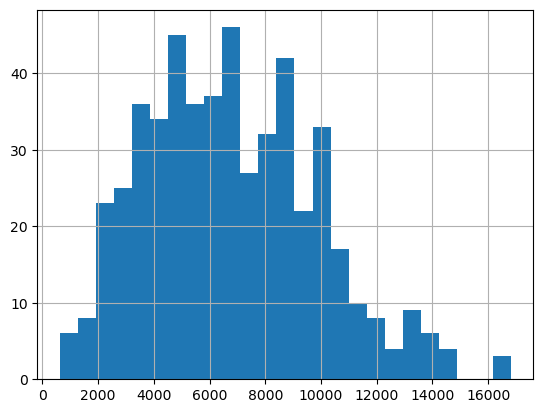

In [39]:
df['sleep_end_s14'].hist(bins=25)

In [40]:
from scipy.stats import normaltest,shapiro


In [ ]:
from scipy.stats import normaltest,shapiro
status,p_val = normaltest(df['sleep_end_s14'])
print('p value is :', p_val)
if p_val.all() > 0.05:
    print('Null hypothesis >> Data is Normally Distributed')
else:
    print('Alternate Hypothesis >> Data is not Normally distributed')


p value is : nan
Null hypothesis >> Data is Normally Distributed


In [42]:
mean =df['sleep_end_s14'].mean()
std = df['sleep_end_s14'].std()
print('mean: ', mean)
print('std: ', std)

print('*'*100)

threshold = 3
outliers = []
for val in df['sleep_end_s14']:
    z_score = (val - mean)/std
    if np.abs(z_score) > threshold:
        outliers.append(val)
        
print('Detected Outliers are:',outliers)

mean:  6774.899264973746
std:  3075.6633873996934
****************************************************************************************************
Detected Outliers are: [16200.930986679889, 16815.960824809816, 16487.51275732871]


In [43]:
q1 = df['sleep_end_s14'].quantile(0.25)
q2 = df['sleep_end_s14'].quantile(0.5)
q3 = df['sleep_end_s14'].quantile(0.75)

print(f'1st Quartile  >> 25th percentile of the data = {q1}')
print(f'2nd Quartile  >> 50th percentile of the data = {q2}')
print(f'3rd Quartile  >> 75th percentile of the data = {q3}')
print('*'*112)

iqr = q3 - q1
print('Inter Quartile Range(IQR): ', iqr)
print('*'*112)

lower_tail = q1 - 3 * iqr #Extreme Outliers
upper_tail = q3 + 3 * iqr #Extreme Outliers
print('Lower tail is :',lower_tail)
print('Upper tail is :',upper_tail)

print('*'*100)

df.reset_index(inplace=True, drop=True)
outliers = []
for i in range(len(df)):
    df.loc[i,'sleep_end_s14']
    if (i > q1+(1.5*iqr)) or (i < q1-(1.5+iqr)):
        outliers.append(i)

print('Outliers for sleep_end_s14: ', outliers)
# sns.boxplot(x= df['sleep_end_s14'])


1st Quartile  >> 25th percentile of the data = 4461.926849332161
2nd Quartile  >> 50th percentile of the data = 6544.358362255722
3rd Quartile  >> 75th percentile of the data = 8807.642161189364
****************************************************************************************************************
Inter Quartile Range(IQR):  4345.715311857203
****************************************************************************************************************
Lower tail is : -8575.21908623945
Upper tail is : 21844.788096760974
****************************************************************************************************
Outliers for sleep_end_s14:  [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84, 85,

In [44]:
df['sleep_end_s14'].describe()

count      513.000000
mean      6774.899265
std       3075.663387
min        630.933375
25%       4461.926849
50%       6544.358362
75%       8807.642161
max      16815.960825
Name: sleep_end_s14, dtype: float64

<Axes: xlabel='sleep_end_s14'>

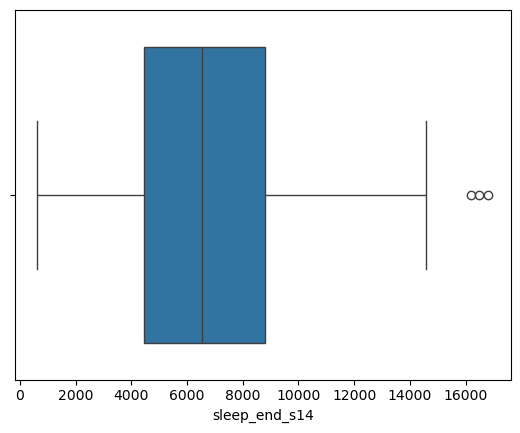

In [45]:
sns.boxplot(x= df['sleep_end_s14'])

In [48]:
sleep_end_s14_df['mean_value'] = 6774.899265

In [49]:
sleep_end_s14_df.mean_value



243    6774.899265
241    6774.899265
Name: mean_value, dtype: float64

In [50]:
sleep_end_s14_df

,feature,base_feature,coefficient,p_value,intercept,intercept_value,r_squared,adj_r_squared,bucket,mean_value
243,sleep_end_s14:C(sex)[Female]:C(age_binary)[young],sleep_end_s14,1.2404,0.000,False,10.6157,0.068,0.061,sleep,6774.899265
241,sleep_end_s14:C(sex)[Female]:C(age_binary)[old],sleep_end_s14,1.1913,0.001,False,10.6157,0.068,0.061,sleep,6774.899265


In [51]:
# PHQ8_total Score = 12.6657 + (coefficient × active_time_m7)
sleep_end_s14_df['Y'] = sleep_end_s14_df['coefficient'] *sleep_end_s14_df['mean_value'] + sleep_end_s14_df['intercept_value']
sleep_end_s14_df

,feature,base_feature,coefficient,p_value,intercept,intercept_value,r_squared,adj_r_squared,bucket,mean_value,Y
243,sleep_end_s14:C(sex)[Female]:C(age_binary)[young],sleep_end_s14,1.2404,0.000,False,10.6157,0.068,0.061,sleep,6774.899265,8414.200748
241,sleep_end_s14:C(sex)[Female]:C(age_binary)[old],sleep_end_s14,1.1913,0.001,False,10.6157,0.068,0.061,sleep,6774.899265,8081.553194


In [52]:
def pd_read_parquet(artifact_path: str) -> pd.DataFrame:
    '''
    This function should read a Parquet file located at the provided path and return a pandas DataFrame.
    '''
    return pd.read_parquet(artifact_path)

path = 'data (1).parquet'
df = pd_read_parquet(path)
df.head()
as_df = df[df.deployment == 'hr-ascent-1']
as_df


,user_id,ts,active_time_m7,active_time_m14,active_time_s7,active_time_s14,activity_percent_m7,activity_percent_m14,activity_percent_s7,activity_percent_s14,...,phq_q4,phq_q5,phq_q6,phq_q7,phq_q8,phq_q9,phq2_total,phq8_total,phq9_total,deployment
0,us-east-1:db841a21-c4fd-cf09-4379-5af0b6185e0e,2024-03-23 21:58:52.242,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,3.0,3.0,2.0,3.0,3.0,1.0,6.0,23.0,24.0,hr-ascent-1
1,us-east-1:db841a21-c48b-cd1c-563f-eb23aa6c2768,2024-03-26 14:46:43.386,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,3.0,3.0,1.0,2.0,2.0,1.0,5.0,19.0,20.0,hr-ascent-1
2,us-east-1:db841a21-c46a-c6fd-ca13-1faabac2c46d,2024-03-27 16:19:40.526,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,3.0,1.0,1.0,1.0,1.0,0.0,4.0,12.0,12.0,hr-ascent-1
3,us-east-1:db841a21-c4b2-c6b9-91ed-370b2da2aa86,2024-03-27 16:42:15.485,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,3.0,3.0,2.0,3.0,1.0,1.0,6.0,21.0,22.0,hr-ascent-1
4,us-east-1:db841a21-c438-c76a-5078-c47a75e6b0c3,2024-03-28 14:52:36.017,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,1.0,1.0,1.0,1.0,1.0,0.0,2.0,7.0,7.0,hr-ascent-1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2919,us-east-1:db841a21-c47e-cfab-1ebe-8283ed8dfd96,2024-09-02 12:02:04.196,6728.571429,9672.857143,4042.834932,5655.600939,0.077877,0.111954,0.046792,0.065458,...,1.0,1.0,1.0,2.0,0.0,2.0,3.0,9.0,11.0,hr-ascent-1
2920,us-east-1:db841a21-c4ab-c3d3-ee67-70a06f76ac36,2024-09-03 22:23:33.343,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,1.0,2.0,1.0,0.0,0.0,0.0,2.0,7.0,7.0,hr-ascent-1
2921,us-east-1:db841a21-c463-c00d-fbe0-780c388ba581,2024-09-04 06:06:08.880,2274.142857,NaN,2178.734145,NaN,0.026321,NaN,0.025217,NaN,...,2.0,2.0,1.0,3.0,2.0,0.0,6.0,19.0,19.0,hr-ascent-1
2922,us-east-1:db841a21-c47d-c6e9-48da-980b0f23abef,2024-09-05 13:38:56.490,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,1.0,0.0,2.0,1.0,1.0,0.0,3.0,9.0,9.0,hr-ascent-1


In [53]:
as_df = df[df.deployment == 'hr-ascent-1']
as_df


,user_id,ts,active_time_m7,active_time_m14,active_time_s7,active_time_s14,activity_percent_m7,activity_percent_m14,activity_percent_s7,activity_percent_s14,...,phq_q4,phq_q5,phq_q6,phq_q7,phq_q8,phq_q9,phq2_total,phq8_total,phq9_total,deployment
0,us-east-1:db841a21-c4fd-cf09-4379-5af0b6185e0e,2024-03-23 21:58:52.242,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,3.0,3.0,2.0,3.0,3.0,1.0,6.0,23.0,24.0,hr-ascent-1
1,us-east-1:db841a21-c48b-cd1c-563f-eb23aa6c2768,2024-03-26 14:46:43.386,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,3.0,3.0,1.0,2.0,2.0,1.0,5.0,19.0,20.0,hr-ascent-1
2,us-east-1:db841a21-c46a-c6fd-ca13-1faabac2c46d,2024-03-27 16:19:40.526,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,3.0,1.0,1.0,1.0,1.0,0.0,4.0,12.0,12.0,hr-ascent-1
3,us-east-1:db841a21-c4b2-c6b9-91ed-370b2da2aa86,2024-03-27 16:42:15.485,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,3.0,3.0,2.0,3.0,1.0,1.0,6.0,21.0,22.0,hr-ascent-1
4,us-east-1:db841a21-c438-c76a-5078-c47a75e6b0c3,2024-03-28 14:52:36.017,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,1.0,1.0,1.0,1.0,1.0,0.0,2.0,7.0,7.0,hr-ascent-1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2919,us-east-1:db841a21-c47e-cfab-1ebe-8283ed8dfd96,2024-09-02 12:02:04.196,6728.571429,9672.857143,4042.834932,5655.600939,0.077877,0.111954,0.046792,0.065458,...,1.0,1.0,1.0,2.0,0.0,2.0,3.0,9.0,11.0,hr-ascent-1
2920,us-east-1:db841a21-c4ab-c3d3-ee67-70a06f76ac36,2024-09-03 22:23:33.343,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,1.0,2.0,1.0,0.0,0.0,0.0,2.0,7.0,7.0,hr-ascent-1
2921,us-east-1:db841a21-c463-c00d-fbe0-780c388ba581,2024-09-04 06:06:08.880,2274.142857,NaN,2178.734145,NaN,0.026321,NaN,0.025217,NaN,...,2.0,2.0,1.0,3.0,2.0,0.0,6.0,19.0,19.0,hr-ascent-1
2922,us-east-1:db841a21-c47d-c6e9-48da-980b0f23abef,2024-09-05 13:38:56.490,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,1.0,0.0,2.0,1.0,1.0,0.0,3.0,9.0,9.0,hr-ascent-1


## Definations replated to descriptive analysis


In [18]:
from scipy.stats import normaltest,shapiro
import numpy as np

# To calculate missing percentage
def calculate_missing_percentage(df, base_feature):
    return (df[base_feature].isna().sum()/len(df)) *100

# Normaltest test
def graph_normaltest_test(df,base_feature):
    status,p_val = normaltest(df[base_feature])
    print('p value is :', p_val)
    if p_val.all() > 0.05:
        result ='Null hypothesis >> Data is Normally Distributed'
    else:
        result = 'Alternate Hypothesis >> Data is not Normally distributed'
    return result

# Outliers using z-scores
def outliers_via_z_score_test(df, base_feature):
    mean = df[base_feature].mean()
    std = df[base_feature].std()

    print(f'Mean of {base_feature}: {mean}')
    print(f'Standard Deviation of {base_feature}: {std}')
    print('*' * 100)

    threshold = 3
    df['z_score'] = (df[base_feature] - mean) / std  # Calculate Z-scores for all values

    # Identify outliers
    outliers = df[np.abs(df['z_score']) > threshold].index.tolist()

    print(f'Outliers for {base_feature}: {outliers}')
    
    # Drop the extra column to keep the DataFrame clean
    df.drop(columns=['z_score'], inplace=True)

    return outliers

# Outliers using IQ
def outliers_via_IQR(df, base_feature):
    q1 = df[base_feature].quantile(0.25)
    q2 = df[base_feature].quantile(0.5)
    q3 = df[base_feature].quantile(0.75)

    print(f'1st Quartile  >> 25th percentile of {base_feature} = {q1}')
    print(f'2nd Quartile  >> 50th percentile (median) of {base_feature} = {q2}')
    print(f'3rd Quartile  >> 75th percentile of {base_feature} = {q3}')
    print('*' * 112)

    iqr = q3 - q1
    print('Inter Quartile Range (IQR): ', iqr)
    print('*' * 112)

    lower_tail = q1 - 1.5 * iqr  # Mild Outliers
    upper_tail = q3 + 1.5 * iqr  # Mild Outliers

    extreme_lower_tail = q1 - 3 * iqr  # Extreme Outliers
    extreme_upper_tail = q3 + 3 * iqr  # Extreme Outliers

    print('Mild Outlier Range:', (lower_tail, upper_tail))
    print('Extreme Outlier Range:', (extreme_lower_tail, extreme_upper_tail))
    print('*' * 100)

    # Detect outliers
    outliers = df[(df[base_feature] < lower_tail) | (df[base_feature] > upper_tail)].index.tolist()

    print(f'Outliers for {base_feature}: ', outliers)

# boxPlot outliers
def box_plot(df, base_feature):
    return sns.boxplot(x= df[base_feature])

# calculate describe of the base_feature
def describe_base_feature(df, base_feature):
    return df[base_feature].describe()

# Plot distribution of the feature
def plot_distrubution(df, base_feature):
    return df[base_feature].hist(bins=25)






            

In [114]:
def cutie():
    pass
print(cutie())

None


## sleep_duration_s14

In [70]:
# Load the data

def pd_read_parquet(artifact_path: str) -> pd.DataFrame:
    '''
    This function should read a Parquet file located at the provided path and return a pandas DataFrame.
    '''
    return pd.read_parquet(artifact_path)

path = 'data (1).parquet'
df = pd_read_parquet(path)
df.head()
sleep_duration_s14_df_as = df[df.deployment == 'hr-ascent-1']
sleep_duration_s14_df_as.head()


,user_id,ts,active_time_m7,active_time_m14,active_time_s7,active_time_s14,activity_percent_m7,activity_percent_m14,activity_percent_s7,activity_percent_s14,...,phq_q4,phq_q5,phq_q6,phq_q7,phq_q8,phq_q9,phq2_total,phq8_total,phq9_total,deployment
0,us-east-1:db841a21-c4fd-cf09-4379-5af0b6185e0e,2024-03-23 21:58:52.242,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,3.0,3.0,2.0,3.0,3.0,1.0,6.0,23.0,24.0,hr-ascent-1
1,us-east-1:db841a21-c48b-cd1c-563f-eb23aa6c2768,2024-03-26 14:46:43.386,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,3.0,3.0,1.0,2.0,2.0,1.0,5.0,19.0,20.0,hr-ascent-1
2,us-east-1:db841a21-c46a-c6fd-ca13-1faabac2c46d,2024-03-27 16:19:40.526,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,3.0,1.0,1.0,1.0,1.0,0.0,4.0,12.0,12.0,hr-ascent-1
3,us-east-1:db841a21-c4b2-c6b9-91ed-370b2da2aa86,2024-03-27 16:42:15.485,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,3.0,3.0,2.0,3.0,1.0,1.0,6.0,21.0,22.0,hr-ascent-1
4,us-east-1:db841a21-c438-c76a-5078-c47a75e6b0c3,2024-03-28 14:52:36.017,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,1.0,1.0,1.0,1.0,1.0,0.0,2.0,7.0,7.0,hr-ascent-1


In [75]:
calculate_missing_percentage(sleep_duration_s14_df_as,'sleep_duration_s14')

82.45554035567716

In [76]:
outliers_via_z_score_test(df =sleep_duration_s14_df_as,base_feature='sleep_duration_s14')

Mean of sleep_duration_s14: 6400.882784218415
Standard Deviation of sleep_duration_s14: 1820.1450270140801
****************************************************************************************************
Outliers for sleep_duration_s14: []


[]

In [77]:
outliers_via_IQR(df =sleep_duration_s14_df_as,base_feature='sleep_duration_s14')

1st Quartile  >> 25th percentile of sleep_duration_s14 = 5161.059819604736
2nd Quartile  >> 50th percentile (median) of sleep_duration_s14 = 6391.911956647912
3rd Quartile  >> 75th percentile of sleep_duration_s14 = 7574.857195912115
****************************************************************************************************************
Inter Quartile Range (IQR):  2413.7973763073787
****************************************************************************************************************
Mild Outlier Range: (1540.3637551436677, 11195.553260373183)
Extreme Outlier Range: (-2080.3323093174004, 14816.24932483425)
****************************************************************************************************
Outliers for sleep_duration_s14:  [931, 1791, 2541, 2804]


In [85]:
sleep_duration_s14_df_as['sleep_duration_s14'].loc[931]

11660.351247230557

In [86]:
sleep_duration_s14_df_as['sleep_duration_s14'].loc[1791]

11404.70550660155

In [87]:
sleep_duration_s14_df_as['sleep_duration_s14'].loc[2541]

11305.15053289555

In [88]:
sleep_duration_s14_df_as['sleep_duration_s14'].loc[2804]

1030.6298085141186

In [93]:
df['sleep_duration_s14'].quantile(0.01)

2267.8958636479856

In [89]:
describe_base_feature(df=sleep_duration_s14_df_as, base_feature='sleep_duration_s14')

count      513.000000
mean      6400.882784
std       1820.145027
min       1030.629809
25%       5161.059820
50%       6391.911957
75%       7574.857196
max      11660.351247
Name: sleep_duration_s14, dtype: float64

<Axes: xlabel='sleep_duration_s14'>

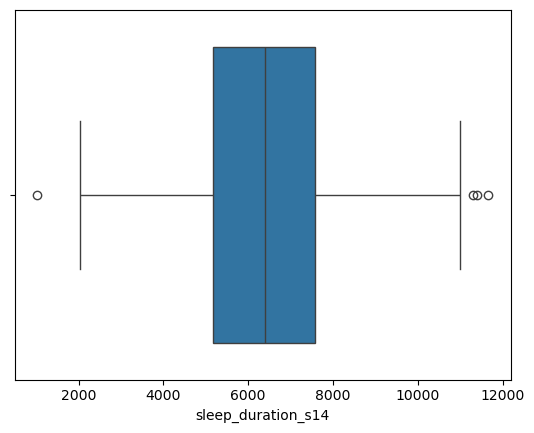

In [78]:
box_plot(df = sleep_duration_s14_df_as, base_feature='sleep_duration_s14')

In [80]:
graph_normaltest_test(df = sleep_duration_s14_df_as, base_feature='sleep_duration_s14')

p value is : nan


'Null hypothesis >> Data is Normally Distributed'

In [ ]:
df_without_nan_values = sleep_duration_s14_df_as[['sleep_duration_s14']]
df_without_nan_values = df_without_nan_values.dropna()
df_without_nan_values
print(len(sleep_duration_s14_df_as))
print(len(df_without_nan_values))
print((len(df_without_nan_values)/len(sleep_duration_s14_df_as)) *100)
print(100-17.54)

,sleep_duration_s14
71,9318.538771
82,5713.474530
101,5806.707944
108,6829.513361
115,6312.350531
...,...
2875,4716.495486
2884,9876.170121
2894,8809.073744
2912,8388.453603


In [101]:
print(len(sleep_duration_s14_df_as))
print(len(df_without_nan_values))
print((len(df_without_nan_values)/len(sleep_duration_s14_df_as)) *100)
print(100-17.54)

2924
513
17.544459644322846
82.46000000000001


In [111]:
df_without_nan_values

,sleep_duration_s14
71,9318.538771
82,5713.474530
101,5806.707944
108,6829.513361
115,6312.350531
...,...
2875,4716.495486
2884,9876.170121
2894,8809.073744
2912,8388.453603


In [116]:
graph_normaltest_test(df= df_without_nan_values, base_feature='sleep_duration_s14')

P-value for sleep_duration_s14: 0.607206


'Null hypothesis accepted >> Data is Normally Distributed ✅'

In [118]:
df_without_nan_values.shape

(513, 1)

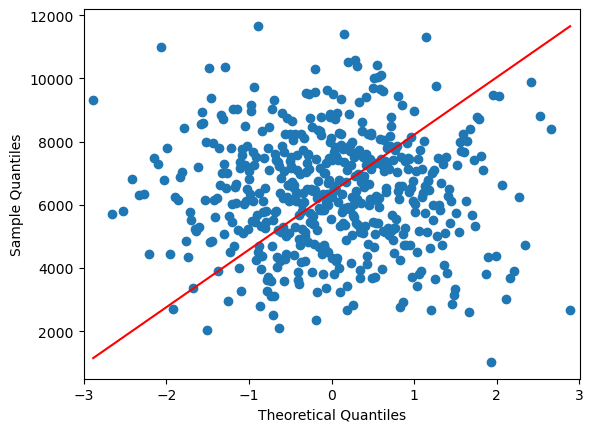

In [ ]:
import statsmodels.api as sm
import matplotlib.pyplot as plt

sm.qqplot(df_without_nan_values, line='s')
plt.show()


# Null Hypothesis:
In short, the Q–Q plot indicates the data is not a perfect normal distribution, but it also doesn’t appear to be severely non-normal. Combined with the statistical test’s p-value, you likely have a distribution that’s “close enough” to normal for many practical purposes, though it’s always wise to keep an eye on potential outliers or skew.

<Axes: >

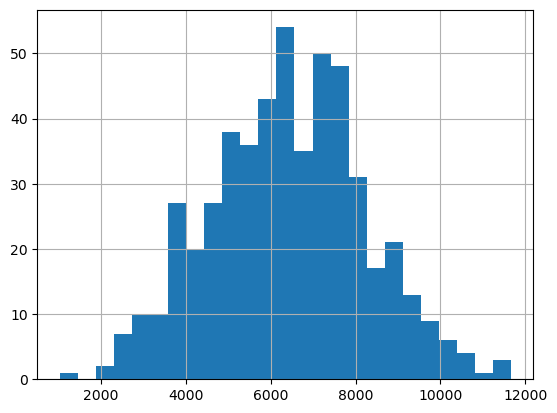

In [82]:
plot_distrubution(df=sleep_duration_s14_df_as,base_feature='sleep_duration_s14')

In [83]:
describe_base_feature(df = sleep_duration_s14_df_as, base_feature='sleep_duration_s14')

count      513.000000
mean      6400.882784
std       1820.145027
min       1030.629809
25%       5161.059820
50%       6391.911957
75%       7574.857196
max      11660.351247
Name: sleep_duration_s14, dtype: float64

In [129]:
sleep_features

,feature,base_feature,coefficient,p_value,intercept,intercept_value,r_squared,adj_r_squared,bucket
243,sleep_end_s14:C(sex)[Female]:C(age_binary)[young],sleep_end_s14,1.2404,0.000,False,10.6157,0.068,0.061,sleep
241,sleep_end_s14:C(sex)[Female]:C(age_binary)[old],sleep_end_s14,1.1913,0.001,False,10.6157,0.068,0.061,sleep
266,sleep_duration_s14:C(sex)[Female]:C(age_binary...,sleep_duration_s14,0.9129,0.003,False,9.4504,0.065,0.058,sleep
268,sleep_duration_s14:C(sex)[Female]:C(age_binary...,sleep_duration_s14,1.1529,0.000,False,9.4504,0.065,0.058,sleep
296,sleep_end_s7:C(sex)[Female]:C(age_binary)[old],sleep_end_s7,1.1564,0.000,False,11.1406,0.056,0.051,sleep
298,sleep_end_s7:C(sex)[Female]:C(age_binary)[young],sleep_end_s7,1.1271,0.000,False,11.1406,0.056,0.051,sleep
281,sleep_start_m14:C(sex)[Female]:C(age_binary)[old],sleep_start_m14,0.7311,0.010,False,6.7092,0.051,0.044,sleep
283,sleep_start_m14:C(sex)[Female]:C(age_binary)[y...,sleep_start_m14,0.7839,0.003,False,6.7092,0.051,0.044,sleep
306,sleep_duration_s7:C(sex)[Female]:C(age_binary)...,sleep_duration_s7,0.9459,0.000,False,10.5212,0.048,0.043,sleep
308,sleep_duration_s7:C(sex)[Female]:C(age_binary)...,sleep_duration_s7,0.9794,0.000,False,10.5212,0.048,0.043,sleep


In [131]:
sleep_features.to_csv('sleep_duration_s7.csv')

## sleep_duration_s7

In [130]:
sleep_duration_s7_df = feature_rankings_filter[feature_rankings_filter.base_feature == 'sleep_duration_s7']
sleep_duration_s7_df

,feature,base_feature,coefficient,p_value,intercept,intercept_value,r_squared,adj_r_squared,bucket
306,sleep_duration_s7:C(sex)[Female]:C(age_binary)...,sleep_duration_s7,0.9459,0.0,False,10.5212,0.048,0.043,sleep
308,sleep_duration_s7:C(sex)[Female]:C(age_binary)...,sleep_duration_s7,0.9794,0.0,False,10.5212,0.048,0.043,sleep


In [135]:
# Load data
def pd_read_parquet(artifact_path: str) -> pd.DataFrame:
    '''
    This function should read a Parquet file located at the provided path and return a pandas DataFrame.
    '''
    return pd.read_parquet(artifact_path)

path = 'data (1).parquet'
df = pd_read_parquet(path)
df.head()
sleep_duration_s7_df_as = df[df.deployment == 'hr-ascent-1']
sleep_duration_s7_df_as.head()


,user_id,ts,active_time_m7,active_time_m14,active_time_s7,active_time_s14,activity_percent_m7,activity_percent_m14,activity_percent_s7,activity_percent_s14,...,phq_q4,phq_q5,phq_q6,phq_q7,phq_q8,phq_q9,phq2_total,phq8_total,phq9_total,deployment
0,us-east-1:db841a21-c4fd-cf09-4379-5af0b6185e0e,2024-03-23 21:58:52.242,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,3.0,3.0,2.0,3.0,3.0,1.0,6.0,23.0,24.0,hr-ascent-1
1,us-east-1:db841a21-c48b-cd1c-563f-eb23aa6c2768,2024-03-26 14:46:43.386,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,3.0,3.0,1.0,2.0,2.0,1.0,5.0,19.0,20.0,hr-ascent-1
2,us-east-1:db841a21-c46a-c6fd-ca13-1faabac2c46d,2024-03-27 16:19:40.526,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,3.0,1.0,1.0,1.0,1.0,0.0,4.0,12.0,12.0,hr-ascent-1
3,us-east-1:db841a21-c4b2-c6b9-91ed-370b2da2aa86,2024-03-27 16:42:15.485,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,3.0,3.0,2.0,3.0,1.0,1.0,6.0,21.0,22.0,hr-ascent-1
4,us-east-1:db841a21-c438-c76a-5078-c47a75e6b0c3,2024-03-28 14:52:36.017,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,1.0,1.0,1.0,1.0,1.0,0.0,2.0,7.0,7.0,hr-ascent-1


In [138]:
sleep_duration_s7_df_as['sleep_duration_s7']

0      NaN
1      NaN
2      NaN
3      NaN
4      NaN
        ..
2919   NaN
2920   NaN
2921   NaN
2922   NaN
2923   NaN
Name: sleep_duration_s7, Length: 2924, dtype: float64

In [140]:
base_feature_1 = 'sleep_duration_s7'

In [141]:
describe_base_feature(df = sleep_duration_s7_df_as, base_feature=base_feature_1)

count      791.000000
mean      6504.601657
std       2285.398296
min        472.077475
25%       4731.195585
50%       6500.879061
75%       8173.869430
max      12737.178427
Name: sleep_duration_s7, dtype: float64

In [142]:
calculate_missing_percentage(df = sleep_duration_s7_df_as, base_feature=base_feature_1)

72.94801641586868

In [ ]:
graph_normaltest_test

## chronotype_score_m7

In [52]:
from scipy.stats import normaltest,shapiro
import numpy as np
import statsmodels.api as sm
import matplotlib.pyplot as plt

# To calculate missing percentage
def calculate_missing_percentage(df, base_feature):
    """
    Calculates and prints the percentage of null and non-null values for a specific column.
    """
    total_rows = len(df)
    null_count = df[base_feature].isna().sum()
    non_null_count = total_rows - null_count
    null_percentage = (null_count / total_rows) * 100
    non_null_percentage = (non_null_count / total_rows) * 100
    
    print(f"Column: {base_feature}")
    print(f"  Null Count: {null_count}")
    print(f"  Null Percentage: {null_percentage:.2f}%")
    print(f"  Non-null Count: {non_null_count}")
    print(f"  Non-null Percentage: {non_null_percentage:.2f}%")
    print("-" * 40)

# Normaltest test
def calculate_null_hypothesis(p_val):
    if p_val.all() > 0.05:
        result ='Null hypothesis >> Data is Normally Distributed'
    else:
        result = 'Alternate Hypothesis >> Data is not Normally distributed'
    return result

def graph_normaltest_test(df,base_feature):
    status,p_val = normaltest(df[base_feature])
    print('p value is :', p_val, type(p_val))
    if np.isnan(p_val):
        print('this is here...')
        df = df[[base_feature]]
        df = df_without_nan_values.dropna()
        status,p_val = normaltest(df[base_feature])
        print('if p value was none dropped na and new p value is :', p_val, type(p_val))
        result = calculate_null_hypothesis(p_val=p_val)
    return result
def graph_shapiro_test(df, base_feature):
    status, p_val = shapiro(df[base_feature])
    print('p-value is:', p_val, type(p_val))
    
    if np.isnan(p_val):
        print('p-value is NaN, handling missing values...')
        df_without_nan = df[[base_feature]].dropna()
        status, p_val = shapiro(df_without_nan[base_feature])
        print('New p-value after dropping NaNs:', p_val, type(p_val))
    
    result = calculate_null_hypothesis(p_val)
    return result

# Outliers using Z-Scores
def outliers_via_z_score_test(df, base_feature):
    mean = df[base_feature].mean()
    std = df[base_feature].std()

    print(f'Mean of {base_feature}: {mean}')
    print(f'Standard Deviation of {base_feature}: {std}')
    
    threshold = 3
    df['z_score'] = (df[base_feature] - mean) / std  # Calculate Z-scores for all values

    # Identify outliers
    outlier_rows = df[np.abs(df['z_score']) > threshold][[base_feature]]

    print(f'Outliers for {base_feature}:')
    print(outlier_rows)
    
    # Drop the extra column to keep the DataFrame clean
    df.drop(columns=['z_score'], inplace=True)

    return outlier_rows.index.tolist(), outlier_rows[base_feature].tolist()

# Outliers using IQR
def outliers_via_IQR(df, base_feature):
    q1 = df[base_feature].quantile(0.25)
    q2 = df[base_feature].quantile(0.5)
    q3 = df[base_feature].quantile(0.75)

    print(f'1st Quartile  >> 25th percentile of {base_feature} = {q1}')
    print(f'2nd Quartile  >> 50th percentile (median) of {base_feature} = {q2}')
    print(f'3rd Quartile  >> 75th percentile of {base_feature} = {q3}')
    print('*' * 112)

    iqr = q3 - q1
    print('Inter Quartile Range (IQR): ', iqr)
    print('*' * 112)

    lower_tail = q1 - 1.5 * iqr  # Mild Outliers
    upper_tail = q3 + 1.5 * iqr  # Mild Outliers

    extreme_lower_tail = q1 - 3 * iqr  # Extreme Outliers
    extreme_upper_tail = q3 + 3 * iqr  # Extreme Outliers

    print('Mild Outlier Range:', (lower_tail, upper_tail))
    print('Extreme Outlier Range:', (extreme_lower_tail, extreme_upper_tail))
    print('*' * 100)

    # Detect outliers
    outlier_rows = df[(df[base_feature] < lower_tail) | (df[base_feature] > upper_tail)][[base_feature]]

    print(f'Outliers for {base_feature}:')
    print(outlier_rows)

    return outlier_rows.index.tolist(), outlier_rows[base_feature].tolist()
# boxPlot outliers
def box_plot(df, base_feature):
    return sns.boxplot(x= df[base_feature])

# calculate describe of the base_feature
def describe_base_feature(df, base_feature):
    return df[base_feature].describe()

# Plot distribution of the feature
def plot_basic_distrubution(df, base_feature):
    return df[base_feature].hist(bins=25)

# Density plot 
def plot_density_graph(df, base_feature):
    sm.qqplot(df[base_feature], line='s')
    plt.show()


In [20]:
# Load data
def pd_read_parquet(artifact_path: str) -> pd.DataFrame:
    '''
    This function should read a Parquet file located at the provided path and return a pandas DataFrame.
    '''
    return pd.read_parquet(artifact_path)

path = 'data (1).parquet'
df = pd_read_parquet(path)
df.head()
chronotype_score_m7_df = df[df.deployment == 'hr-ascent-1']
chronotype_score_m7_df.head()

,user_id,ts,active_time_m7,active_time_m14,active_time_s7,active_time_s14,activity_percent_m7,activity_percent_m14,activity_percent_s7,activity_percent_s14,...,phq_q4,phq_q5,phq_q6,phq_q7,phq_q8,phq_q9,phq2_total,phq8_total,phq9_total,deployment
0,us-east-1:db841a21-c4fd-cf09-4379-5af0b6185e0e,2024-03-23 21:58:52.242,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,3.0,3.0,2.0,3.0,3.0,1.0,6.0,23.0,24.0,hr-ascent-1
1,us-east-1:db841a21-c48b-cd1c-563f-eb23aa6c2768,2024-03-26 14:46:43.386,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,3.0,3.0,1.0,2.0,2.0,1.0,5.0,19.0,20.0,hr-ascent-1
2,us-east-1:db841a21-c46a-c6fd-ca13-1faabac2c46d,2024-03-27 16:19:40.526,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,3.0,1.0,1.0,1.0,1.0,0.0,4.0,12.0,12.0,hr-ascent-1
3,us-east-1:db841a21-c4b2-c6b9-91ed-370b2da2aa86,2024-03-27 16:42:15.485,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,3.0,3.0,2.0,3.0,1.0,1.0,6.0,21.0,22.0,hr-ascent-1
4,us-east-1:db841a21-c438-c76a-5078-c47a75e6b0c3,2024-03-28 14:52:36.017,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,1.0,1.0,1.0,1.0,1.0,0.0,2.0,7.0,7.0,hr-ascent-1


In [22]:
base_feature = 'chronotype_score_m7'


<Axes: >

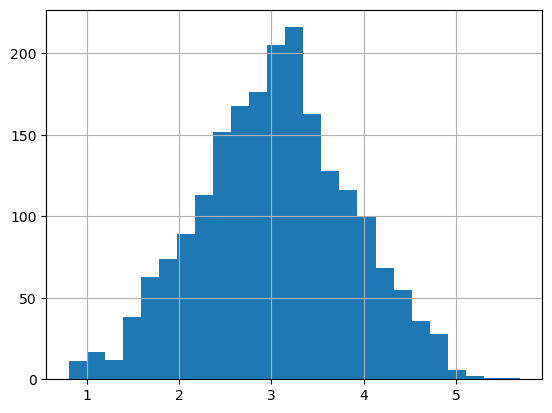

In [24]:
# Data distribution
plot_basic_distrubution(df=chronotype_score_m7_df, base_feature=base_feature)

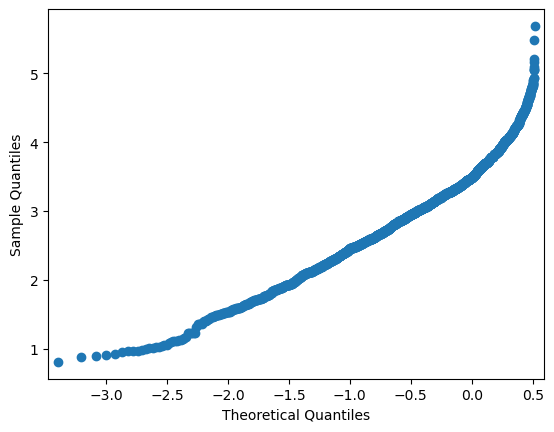

In [27]:
plot_density_graph(df=chronotype_score_m7_df, base_feature=base_feature)

In [28]:
# description stats
describe_base_feature(df=chronotype_score_m7_df, base_feature=base_feature)

count    2038.000000
mean        3.044300
std         0.815766
min         0.808571
25%         2.496071
50%         3.054286
75%         3.596786
max         5.690000
Name: chronotype_score_m7, dtype: float64

In [45]:
# Normality Test
graph_normaltest_test(df=chronotype_score_m7_df, base_feature=base_feature)

p value is : nan <class 'numpy.float64'>
this is here...
if p value was none dropped na and new p value is : 0.025912987855684452 <class 'numpy.float64'>


'Null hypothesis >> Data is Normally Distributed'

In [46]:
graph_shapiro_test(df=chronotype_score_m7_df, base_feature=base_feature)

p-value is: nan <class 'numpy.float64'>
p-value is NaN, handling missing values...
New p-value after dropping NaNs: 0.006735086787120442 <class 'numpy.float64'>


'Null hypothesis >> Data is Normally Distributed'

In [30]:
df_without_nan_values = chronotype_score_m7_df[['chronotype_score_m7']]
df_without_nan_values = df_without_nan_values.dropna()
df_without_nan_values
# print(len(sleep_duration_s14_df_as))
# print(len(df_without_nan_values))
# print((len(df_without_nan_values)/len(sleep_duration_s14_df_as)) *100)
# print(100-17.54)

,chronotype_score_m7
71,3.344286
82,1.945714
89,3.642857
90,2.744286
96,2.320000
...,...
2916,4.017143
2918,3.284286
2919,2.268571
2922,2.840000


In [ ]:
print(len(chronotype_score_m7_df))
print(len(df_without_nan_values))
print((len(df_without_nan_values)/len(sleep_duration_s14_df_as)) *100)
print(100-17.54)

In [ ]:

calculate_missing_percentage(df=chronotype_score_m7_df, base_feature=base_feature)


Column: chronotype_score_m7
  Null Count: 886
  Null Percentage: 30.30%
  Non-null Count: 2038
  Non-null Percentage: 69.70%
----------------------------------------


In [53]:
# Outlier Identification
print("Outliers via z-score test")
index,val = outliers_via_z_score_test(df=chronotype_score_m7_df, base_feature=base_feature)
print(index)
print(val)
print('-'*40)
print('-'*40)
print('-'*40)
print("Outliers via IQR test")
index,val = outliers_via_IQR(df=chronotype_score_m7_df, base_feature=base_feature)
print(index)
print(val)


Outliers via z-score test
Mean of chronotype_score_m7: 3.0442997336324127
Standard Deviation of chronotype_score_m7: 0.8157658659729835
Outliers for chronotype_score_m7:
      chronotype_score_m7
1034                 5.69
[1034]
[5.6899999999999995]
----------------------------------------
----------------------------------------
----------------------------------------
Outliers via IQR test
1st Quartile  >> 25th percentile of chronotype_score_m7 = 2.4960714285714287
2nd Quartile  >> 50th percentile (median) of chronotype_score_m7 = 3.0542857142857143
3rd Quartile  >> 75th percentile of chronotype_score_m7 = 3.5967857142857143
****************************************************************************************************************
Inter Quartile Range (IQR):  1.1007142857142855
****************************************************************************************************************
Mild Outlier Range: (0.8450000000000004, 5.247857142857143)
Extreme Outlier Range: (-0.8060

In [56]:
df.iloc[1034].to_dict()

{'user_id': 'us-east-1:6793997d-cb82-40fc-a8b0-1dc5173bddf0',
 'ts': Timestamp('2019-04-19 00:48:38.588000'),
 'active_time_m7': 2220.0,
 'active_time_m14': 2344.285714285714,
 'active_time_s7': 1638.4138671288154,
 'active_time_s14': 1729.6185185699815,
 'activity_percent_m7': 0.02569444445714286,
 'activity_percent_m14': 0.027132936514285715,
 'activity_percent_s7': 0.018963123478347173,
 'activity_percent_s14': 0.020018732867233432,
 'chronotype_score_m7': 1.6771428571428573,
 'chronotype_score_m14': 1.5742857142857143,
 'chronotype_score_s7': 0.1511857892036911,
 'chronotype_score_s14': 0.31161401878493317,
 'display_events_m7': 141.85714285714286,
 'display_events_m14': 117.28571428571429,
 'display_events_s7': 84.3453783982433,
 'display_events_s14': 92.34586207166103,
 'ec_Activity_m7': 457.7142857142857,
 'ec_Activity_m14': 409.0,
 'ec_Activity_s7': 353.34719200134873,
 'ec_Activity_s14': 294.54737114113544,
 'ec_DeviceDisplayStatus_m7': 141.85714285714286,
 'ec_DeviceDisplaySt

<Axes: xlabel='chronotype_score_m7'>

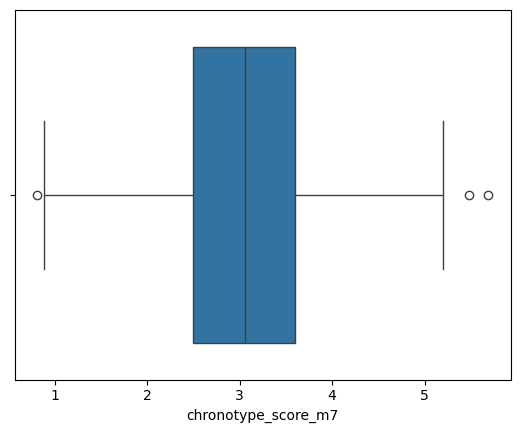

In [54]:
box_plot(df=chronotype_score_m7_df, base_feature=base_feature)

In [58]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from functools import wraps


In [65]:
df = pd.read_parquet('data (1).parquet')
print('orignal dataframe shape: ',df.shape)

df = df[df.deployment == 'hr-ascent-1']
print('Ascent dataframe shape: ',df.shape)

orignal dataframe shape:  (6820, 158)
Ascent dataframe shape:  (2924, 158)


In [81]:

# Decorator to validate column existence
def validate_column(func):
    @wraps(func)
    def wrapper(self, column, *args, **kwargs):
        if column not in self.df.columns:
            raise ValueError(f"Column '{column}' not found in DataFrame")
        return func(self, column, *args, **kwargs)
    return wrapper

class DataAnalyzer:
    def __init__(self, dataframe):
        self.df = dataframe
        self._normality_results = {}
        self._null_summary = None
        self._statistical_summary = None
        
    # Class method to create instance from CSV (example of class method)
    @classmethod
    def from_csv(cls, file_path):
        df = pd.read_csv(file_path)
        return cls(df)
    
    @property
    def null_summary(self):
        """Lazy-loaded null analysis summary"""
        if self._null_summary is None:
            self._null_summary = self._compute_null_summary()
        return self._null_summary
    
    def _compute_null_summary(self):
        null_percent = self.df.isnull().mean() * 100
        return pd.DataFrame({
            '% Missing': null_percent,
            '% Available': 100 - null_percent
        }).round(2)
    
    @validate_column
    def get_column_data(self, column):
        """Convert column to numeric and clean data"""
        return pd.to_numeric(self.df[column], errors='coerce').dropna()
    
    @validate_column
    def plot_distribution(self, column):
        """Instance method to plot distribution for specific column"""
        data = self.get_column_data(column)
        
        plt.figure(figsize=(12, 5))
        plt.subplot(1, 2, 1)
        sns.histplot(data, kde=False, bins=30)
        plt.title(f'Histogram of {column}')
        
        plt.subplot(1, 2, 2)
        sns.kdeplot(data, fill=True)
        plt.title(f'Density Plot of {column}')
        
        plt.tight_layout()
        plt.show()
        
        print(f"Skewness of {column}: {data.skew():.2f}\n")
        return self  # Allows method chaining
    
    @validate_column
    def test_normality(self, column, force_retest=False):
        """Test normality with caching"""
        if not force_retest and column in self._normality_results:
            return self._normality_results[column]
        
        data = self.get_column_data(column)
        if len(data) < 8:
            raise ValueError("Insufficient data for normality test")
            
        k2_stat, p_value = stats.normaltest(data)
        result = {
            'test_statistic': k2_stat,
            'p_value': p_value,
            'normality': 'Accepted' if p_value >= 0.05 else 'Rejected'
        }
        self._normality_results[column] = result
        return result
    
    @validate_column
    def detect_outliers(self, column):
        """Outlier detection with automatic method selection"""
        data = self.get_column_data(column)
        normality_result = self.test_normality(column)
        
        if 0.02 < normality_result['p_value'] <= 1: 
            return self._zscore_outliers(data, column)
        return self._iqr_outliers(data, column)
    
    def _zscore_outliers(self, data, column):
        """Private method for Z-score outlier detection"""
        z_scores = np.abs(stats.zscore(data))
        outliers = data[z_scores > 3]
        return {
            'column': column,
            'method': 'Z-score',
            'outliers': outliers.tolist(),
            'count': len(outliers)
        }
    
    def _iqr_outliers(self, data, column):
        """Private method for IQR outlier detection"""
        Q1 = data.quantile(0.25)
        Q3 = data.quantile(0.75)
        IQR = Q3 - Q1
        lower = Q1 - 1.5 * IQR
        upper = Q3 + 1.5 * IQR
        outliers = data[(data < lower) | (data > upper)]
        return {
            'column': column,
            'method': 'IQR',
            'outliers': outliers.tolist(),
            'count': len(outliers)
        }
    
    @validate_column
    def get_statistics(self, column):
        """Get comprehensive statistics for a column"""
        data = self.get_column_data(column)
        stats = data.describe().to_dict()
        stats.update({
            'variance': data.var(),
            'skewness': data.skew(),
            'kurtosis': data.kurtosis(),
            'iqr': data.quantile(0.75) - data.quantile(0.25)
        })
        return {k: round(v, 2) if isinstance(v, float) else v 
                for k, v in stats.items()}

    def get_null_ratio(self, column):
            """Calculate null ratio for specific column"""
            col_series = self.df[column]
            null_count = col_series.isnull().sum()
            total = len(col_series)
            return {
                'null_pct': round((null_count / total) * 100, 2),
                'non_null_pct': round(100 - (null_count / total) * 100, 2)
            }

    
    def full_analysis(self, column):
            """Composite method to run all analyses for a column"""
            print(f"\n{'='*40}\nAnalysis for {column}\n{'='*40}")
            
            # Null value analysis
            null_ratio = self.get_null_ratio(column)
            print(f"Null Values Analysis:")
            print(f"- Missing Values: {null_ratio['null_pct']}%")
            print(f"- Available Values: {null_ratio['non_null_pct']}%\n")
            
            # Distribution analysis
            self.plot_distribution(column)
            
            # Normality test
            normality = self.test_normality(column)
            print(f"Normality Test Results ({column}):")
            print(f"Statistic: {normality['test_statistic']:.2f}, p-value: {normality['p_value']:.4f}")
            print(f"Conclusion: {normality['normality']}\n")
            
            # Outlier detection
            outliers = self.detect_outliers(column)
            print(f"Outlier Analysis ({column}):")
            print(f"Method: {outliers['method']}")
            print(f"Found {outliers['count']} outliers\n")
            
            # Statistical summary
            stats = self.get_statistics(column)
            print(f"Statistical Summary ({column}):")
            for k, v in stats.items():
                print(f"{k.capitalize()}: {v}")
                
            return self


Analysis for chronotype_score_m7
Null Values Analysis:
- Missing Values: 30.3%
- Available Values: 69.7%



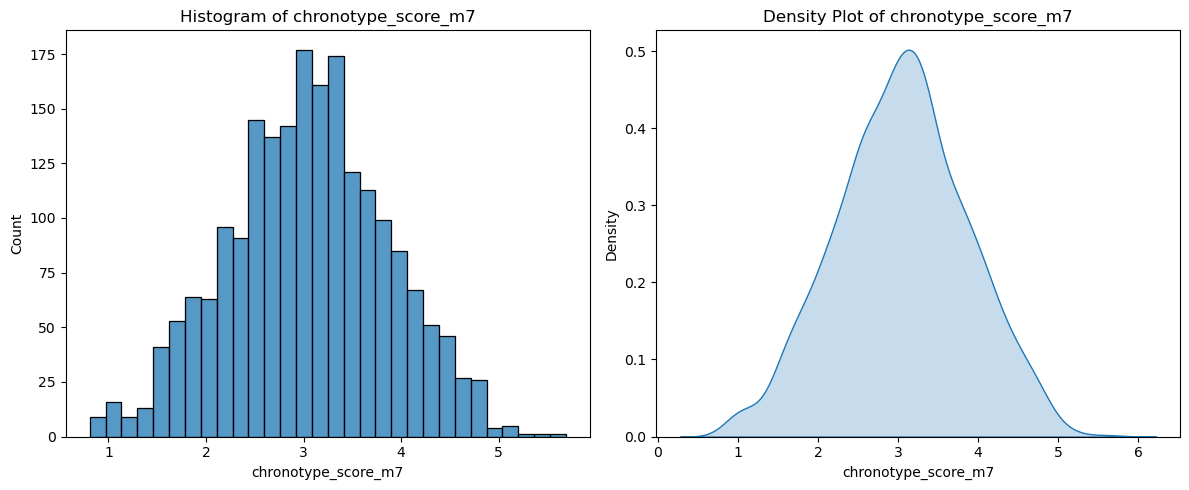

Skewness of chronotype_score_m7: -0.03

Normality Test Results (chronotype_score_m7):
Statistic: 7.31, p-value: 0.0259
Conclusion: Rejected

Outlier Analysis (chronotype_score_m7):
Method: Z-score
Found 1 outliers

Statistical Summary (chronotype_score_m7):
Count: 2038.0
Mean: 3.04
Std: 0.82
Min: 0.81
25%: 2.5
50%: 3.05
75%: 3.6
Max: 5.69
Variance: 0.67
Skewness: -0.03
Kurtosis: -0.25
Iqr: 1.1


In [82]:
if __name__ == "__main__":    
    analyzer = DataAnalyzer(df)
    analyzer.full_analysis('chronotype_score_m7')


Analysis for chronotype_score_s7
Null Values Analysis:
- Missing Values: 30.3%
- Available Values: 69.7%



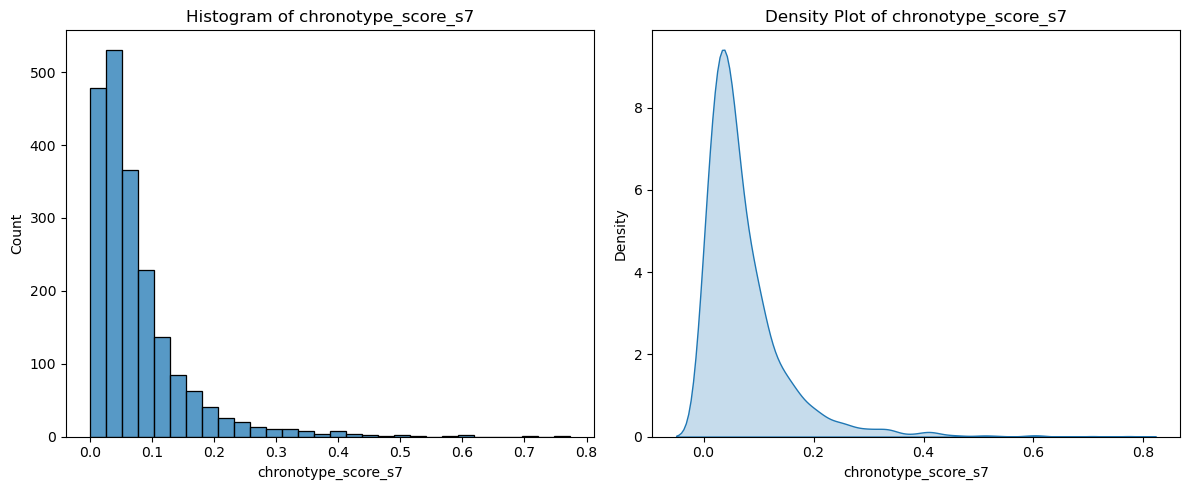

Skewness of chronotype_score_s7: 2.94

Normality Test Results (chronotype_score_s7):
Statistic: 1342.07, p-value: 0.0000
Conclusion: Rejected

Outlier Analysis (chronotype_score_s7):
Method: IQR
Found 130 outliers

Statistical Summary (chronotype_score_s7):
Count: 2038.0
Mean: 0.07
Std: 0.08
Min: 0.0
25%: 0.03
50%: 0.05
75%: 0.09
Max: 0.77
Variance: 0.01
Skewness: 2.94
Kurtosis: 13.73
Iqr: 0.07


In [83]:
analyzer.full_analysis('chronotype_score_s7')


Analysis for chronotype_score_m14
Null Values Analysis:
- Missing Values: 41.72%
- Available Values: 58.28%



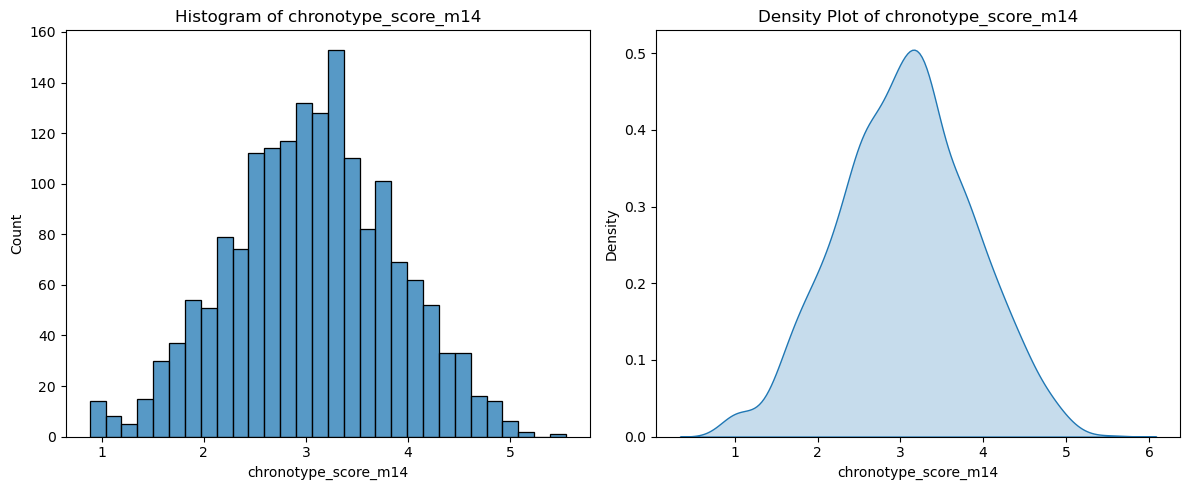

Skewness of chronotype_score_m14: -0.04

Normality Test Results (chronotype_score_m14):
Statistic: 6.41, p-value: 0.0406
Conclusion: Rejected

Outlier Analysis (chronotype_score_m14):
Method: Z-score
Found 1 outliers

Statistical Summary (chronotype_score_m14):
Count: 1704.0
Mean: 3.06
Std: 0.8
Min: 0.88
25%: 2.51
50%: 3.07
75%: 3.61
Max: 5.54
Variance: 0.64
Skewness: -0.04
Kurtosis: -0.25
Iqr: 1.1


In [84]:
analyzer.full_analysis('chronotype_score_m14')

In [57]:
describe_base_feature(df=chronotype_score_m7_df, base_feature=base_feature)

count    2038.000000
mean        3.044300
std         0.815766
min         0.808571
25%         2.496071
50%         3.054286
75%         3.596786
max         5.690000
Name: chronotype_score_m7, dtype: float64

In [19]:
as_df.columns.to_list()

NameError: name 'as_df' is not defined

In [ ]:
import pandas as pd
from datetime import datetime, timedelta

# Generate synthetic data for sleep proxy inference
num_samples = 10  # Define the number of samples

data = {
    'sp_start_display': [datetime(2025, 3, 30, 22, 0) + timedelta(minutes=i*10) for i in range(num_samples)],
    'sp_start_activity': [datetime(2025, 3, 30, 22, 5) + timedelta(minutes=i*10) for i in range(num_samples)],
    'sp_end_display': [datetime(2025, 3, 31, 6, 0) + timedelta(minutes=i*10) for i in range(num_samples)],
    'sp_end_activity': [datetime(2025, 3, 31, 6, 5) + timedelta(minutes=i*10) for i in range(num_samples)]
}

# Convert to DataFrame
df = pd.DataFrame(data)

# Introduce some None values to simulate missing data
df.loc[2, 'sp_start_display'] = None
df.loc[5, 'sp_end_activity'] = None

print(df)

     sp_start_display   sp_start_activity      sp_end_display  \
0 2025-03-30 22:00:00 2025-03-30 22:05:00 2025-03-31 06:00:00   
1 2025-03-30 22:10:00 2025-03-30 22:15:00 2025-03-31 06:10:00   
2                 NaT 2025-03-30 22:25:00 2025-03-31 06:20:00   
3 2025-03-30 22:30:00 2025-03-30 22:35:00 2025-03-31 06:30:00   
4 2025-03-30 22:40:00 2025-03-30 22:45:00 2025-03-31 06:40:00   
5 2025-03-30 22:50:00 2025-03-30 22:55:00 2025-03-31 06:50:00   
6 2025-03-30 23:00:00 2025-03-30 23:05:00 2025-03-31 07:00:00   
7 2025-03-30 23:10:00 2025-03-30 23:15:00 2025-03-31 07:10:00   
8 2025-03-30 23:20:00 2025-03-30 23:25:00 2025-03-31 07:20:00   
9 2025-03-30 23:30:00 2025-03-30 23:35:00 2025-03-31 07:30:00   

      sp_end_activity  
0 2025-03-31 06:05:00  
1 2025-03-31 06:15:00  
2 2025-03-31 06:25:00  
3 2025-03-31 06:35:00  
4 2025-03-31 06:45:00  
5                 NaT  
6 2025-03-31 07:05:00  
7 2025-03-31 07:15:00  
8 2025-03-31 07:25:00  
9 2025-03-31 07:35:00  


In [ ]:
df_sm = pd.read_csv('summary.csv')

In [ ]:
df_sm.columns.tolist()

['Unnamed: 0',
 'active_time',
 'activity_automotive_count',
 'activity_automotive_max',
 'activity_automotive_mean',
 'activity_automotive_min',
 'activity_automotive_std',
 'activity_automotive_sum',
 'activity_cycling_count',
 'activity_cycling_max',
 'activity_cycling_mean',
 'activity_cycling_min',
 'activity_cycling_std',
 'activity_cycling_sum',
 'activity_percent',
 'activity_reboot_count',
 'activity_reboot_max',
 'activity_reboot_mean',
 'activity_reboot_min',
 'activity_reboot_std',
 'activity_reboot_sum',
 'activity_running_count',
 'activity_running_max',
 'activity_running_mean',
 'activity_running_min',
 'activity_running_std',
 'activity_running_sum',
 'activity_stationary_count',
 'activity_stationary_max',
 'activity_stationary_mean',
 'activity_stationary_min',
 'activity_stationary_std',
 'activity_stationary_sum',
 'activity_tilting_count',
 'activity_tilting_max',
 'activity_tilting_mean',
 'activity_tilting_min',
 'activity_tilting_std',
 'activity_tilting_sum',


   'sp_start_display': [datetime(2025, 3, 30, 22, 0) + timedelta(minutes=i*10) for i in range(num_samples)],
    'sp_start_activity': [datetime(2025, 3, 30, 22, 5) + timedelta(minutes=i*10) for i in range(num_samples)],
    'sp_end_display': [datetime(2025, 3, 31, 6, 0) + timedelta(minutes=i*10) for i in range(num_samples)],
    'sp_end_activity'

In [ ]:
df_s_1 = df_sm[['user_id','sp_start_display', 'sp_start_activity', 'sp_end_display', 'sp_end_activity','date']]

In [ ]:
df_s_1

,user_id,sp_start_display,sp_start_activity,sp_end_display,sp_end_activity,date
0,us-east-1:db841a21-c407-c0e5-a83d-7cd2cd6853b7,True,2024-05-09T16:14:52.911000,True,2024-05-09T16:42:29.076000,2024-05-10
1,us-east-1:db841a21-c407-c0e5-a83d-7cd2cd6853b7,True,True,True,True,2024-05-11
2,us-east-1:db841a21-c407-c0e5-a83d-7cd2cd6853b7,2024-05-12T19:58:44.501000,2024-05-12T13:56:15.960000,2024-05-12T20:02:33.677000,2024-05-12T19:12:22.111000,2024-05-12
3,us-east-1:db841a21-c407-c0e5-a83d-7cd2cd6853b7,2024-05-12T19:58:44.501000,2024-05-12T20:02:03.269000,2024-05-12T20:02:33.677000,2024-05-13T14:30:31.467000,2024-05-13
4,us-east-1:db841a21-c407-c0e5-a83d-7cd2cd6853b7,True,2024-05-14T16:45:04.127000,True,2024-05-14T20:08:52.479000,2024-05-14
...,...,...,...,...,...,...
114734,us-east-1:db841a21-c4d5-c76c-b22b-0656fb5a9789,True,True,True,True,2024-10-17
114735,us-east-1:db841a21-c4d5-c76c-b22b-0656fb5a9789,True,True,True,True,2024-10-18
114736,us-east-1:db841a21-c4d5-c76c-b22b-0656fb5a9789,True,True,True,True,2024-10-19
114737,us-east-1:db841a21-c4d5-c76c-b22b-0656fb5a9789,True,True,True,True,2024-10-20


In [ ]:
df 

,user_id,ts,active_time_m7,active_time_m14,active_time_s7,active_time_s14,activity_percent_m7,activity_percent_m14,activity_percent_s7,activity_percent_s14,...,phq_q4,phq_q5,phq_q6,phq_q7,phq_q8,phq_q9,phq2_total,phq8_total,phq9_total,deployment
0,us-east-1:1b087523-b47b-421c-97c4-74da80564598,2018-09-25 18:17:26.647000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,2.0,0.0,1.0,1.0,1.0,NaN,3.0,9.0,NaN,hr-rct-cue-1
1,us-east-1:ea986d8e-e87d-458b-a798-1999fbbff05b,2018-09-26 17:13:52.394000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,3.0,3.0,3.0,3.0,3.0,NaN,4.0,21.0,NaN,hr-rct-cue-1
2,us-east-1:8dfca9b6-22b6-4155-8a70-ce3e1211a684,2018-09-27 19:04:15.124000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,3.0,3.0,3.0,3.0,1.0,NaN,6.0,22.0,NaN,hr-rct-cue-1
3,us-east-1:77f43bb4-fe8e-4a50-a4fc-41bc14b11f9d,2018-10-01 22:01:32.622000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,2.0,1.0,2.0,2.0,0.0,NaN,2.0,10.0,NaN,hr-rct-cue-1
4,us-east-1:4940dfa3-1c01-49f2-9cdd-029291d7b7a8,2018-10-05 21:08:52.441000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,2.0,3.0,3.0,1.0,0.0,NaN,6.0,18.0,NaN,hr-rct-cue-1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1507,us-east-1:db841a21-c452-c3d4-f82c-773d4ed8805f,2024-04-23 17:10:30.859001,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.0,0.0,0.0,3.0,0.0,0.0,1.0,4.0,4.0,hr-uchealth-1
1508,us-east-1:db841a21-c447-c546-5505-f39437315109,2024-04-24 22:30:24.258001,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,2.0,2.0,3.0,3.0,0.0,3.0,5.0,18.0,21.0,hr-uchealth-1
1509,us-east-1:db841a21-c4f8-c359-4d5c-97de2759e13b,2024-04-28 18:35:41.677001,4891.714286,5070.071428,1814.986573,1642.477750,0.056617,0.058681,0.021007,0.019010,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,1.0,hr-uchealth-1
1510,us-east-1:db841a21-c469-cee5-525d-e2e262014c84,2024-05-02 14:34:38.731001,3008.571429,2704.285714,1348.967859,1996.430331,0.034821,0.031300,0.015613,0.023107,...,1.0,1.0,1.0,1.0,0.0,0.0,2.0,7.0,7.0,hr-uchealth-1


In [ ]:
df= as_df

In [ ]:


# Set random seed for reproducibility
np.random.seed(42)
import pandas as pd
import numpy as np

# Print column names for debugging
print("Columns in dataset:", df.columns.tolist())

# Ensure 'deployment' column is removed if it exists
if "deployment" in df.columns:
    df = df.drop(columns=["deployment"])

# Set random seed for reproducibility
np.random.seed(42)

# Function to obfuscate numerical columns while maintaining statistical properties
def obfuscate_numerical(column):
    std_dev = df[column].std()
    return df[column] + np.random.normal(0, std_dev * 0.1, size=len(df))

# Apply obfuscation to all numerical columns
for col in df.select_dtypes(include=['int64', 'float64']).columns:
    df[col] = obfuscate_numerical(col)
    df[col] = df[col].clip(lower=0)  # Ensure values stay non-negative

# Function to shuffle categorical values to anonymize data
def shuffle_categorical(column):
    df[column] = np.random.permutation(df[column].values)

# Apply shuffling to all categorical columns
for col in df.select_dtypes(include=['object']).columns:
    shuffle_categorical(col)


# df.to_csv("modified_dataset.csv", index=False)


In [ ]:
df

In [ ]:
from datetime import datetime, timedelta

# Print column names for debugging
print("Columns in dataset:", df.columns.tolist())

# Shift date column by 3 months and change the year if it exists
if "ts" in df.columns:
    df["ts"] = pd.to_datetime(df["ts"]) + pd.DateOffset(months=3)
    df["ts"] = df["ts"].apply(lambda x: x.replace(year=x.year + 1))

df

In [ ]:
def replace_region(text):
    if isinstance(text, str):
        return re.sub(r'\bus-east-1\b', 'aus-south-4', text)
    return text

# Apply the replacement function to all string columns
df["user_id"] = df["user_id"].apply(replace_region)

In [ ]:
df

In [ ]:
df.to_csv("dataset.csv", index=False)

In [ ]:
def pd_read_parquet(artifact_path: str) -> pd.DataFrame:
    '''
    This function should read a Parquet file located at the provided path and return a pandas DataFrame.
    '''
    return pd.read_parquet(artifact_path)

path = 'data (1).parquet'
df = pd_read_parquet(path)
df.head()
as_df1 = df[df.deployment == 'hr-ascent-1']
as_df1

In [ ]:
df = as_df1

In [ ]:
import pandas as pd
import numpy as np
import re
from datetime import datetime, timedelta




# Print column names for debugging
print("Columns in dataset:", df.columns.tolist())

# Shift date column by 3 months and change the year if it exists
if "ts" in df.columns:
    df["ts"] = pd.to_datetime(df["ts"]) + pd.DateOffset(months=3)
    df["ts"] = df["ts"].apply(lambda x: x.replace(year=x.year + 1))

# Function to replace 'us-east-1' with 'aus-south-4' in the user_id column only
def replace_region(text):
    if isinstance(text, str):
        return re.sub(r'\bus-east-1\b', 'aus-south-4', text)
    return text

# Apply the replacement function to user_id column only
if "user_id" in df.columns:
    df["user_id"] = df["user_id"].apply(replace_region)

# Modify all columns except PHQ columns
phq_columns = [col for col in df.columns if col.startswith("phq")]  # Identify PHQ columns
non_phq_columns = [col for col in df.columns if col not in phq_columns]

# Function to modify numerical data by adding random noise
def obfuscate_numerical(column):
    if df[column].dtype in ['int64', 'float64']:
        return df[column] + np.random.uniform(-10, 10, df.shape[0])
    return df[column]

# Apply modifications to all non-PHQ columns
for col in non_phq_columns:
    if col == "ts":
        continue  # Skip timestamp as it is already modified
    df[col] = obfuscate_numerical(col)

# Save the modified dataset
# df.to_csv("modified_dataset.csv", index=False)


In [ ]:
df